# Situación 1: NeuroLingua AI

## Contexto del Problema
**NeuroLingua AI** es un modelo de lenguaje avanzado. Queremos entender la relación entre:
1.  **Evaluación Humana (`hum_eval`):** 20 evaluadores califican la calidad de las respuestas (subjetivo).
2.  **Métricas Internas (`int_metric`):** 2,980 métricas técnicas generadas por el modelo (objetivo).

**Objetivo:** Descubrir si existe una estructura latente que conecte la percepción humana con el comportamiento interno del modelo.

## Herramientas
Importamos las librerías esenciales para manipulación de datos y visualización.

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import jinja2

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [46]:
import os

IMG_PATH = '/home/yeigen/Documents/proyecto_1_analitica/situacion1/imagenes/'
os.makedirs(IMG_PATH, exist_ok=True)

print(f"Esta es la ruta para los gráficos: {IMG_PATH}")

Esta es la ruta para los gráficos: /home/yeigen/Documents/proyecto_1_analitica/situacion1/imagenes/


## Paso 2: Carga de Datos

Cargamos el dataset `neuro_lingua_ai.csv` en un DataFrame de pandas. Este archivo contiene las **3,000 observaciones** con las columnas de evaluación humana (`hum_eval`) y métricas internas (`int_metric`).

Visualizamos las primeras 5 filas para verificar que la carga fue correcta.

In [47]:
df = pd.read_csv("/home/yeigen/Documents/proyecto_1_analitica/situacion1/data/neuro_lingua_ai.csv")
df.head()

,prompt_id,hum_eval_1,hum_eval_2,hum_eval_3,hum_eval_4,hum_eval_5,hum_eval_6,hum_eval_7,hum_eval_8,hum_eval_9,...,int_metric_2971,int_metric_2972,int_metric_2973,int_metric_2974,int_metric_2975,int_metric_2976,int_metric_2977,int_metric_2978,int_metric_2979,int_metric_2980
0,1,-0.339186,-0.287385,0.728980,0.860822,1.186173,2.184202,1.427158,2.025146,0.992884,...,-0.192521,3.378995,-2.321888,1.960685,2.307434,2.063464,-0.769745,2.306955,0.465841,2.400956
1,2,0.574710,0.308417,0.525689,-1.776930,0.244834,-0.726710,-0.790432,-1.359604,0.137254,...,-2.239109,-0.014281,-3.644794,4.522159,1.913035,5.217038,-1.137459,3.965600,-1.103022,-0.563290
2,3,1.271335,-0.691080,2.078729,1.061050,0.469707,0.083061,0.706240,1.719755,0.550976,...,-1.905571,1.128669,-4.492878,-5.977465,-1.977145,-4.627741,-0.021282,0.085709,1.739209,-2.410995
3,4,-0.906492,0.478097,0.386307,-0.788879,-0.179730,0.677334,-0.508968,0.142613,-0.040164,...,-1.002625,-0.141350,-2.113565,4.067415,3.319028,6.946003,-2.629901,0.538554,1.666984,-1.175855
4,5,-0.102369,0.117190,0.994496,1.092337,-0.332661,0.586530,-0.525498,-2.120068,0.092944,...,2.563492,-0.487197,-4.773471,1.875335,3.157106,1.962328,1.945696,-1.474450,-1.237909,-0.959168


## Paso 3: Inspección Inicial de los Datos (EDA)

Antes de cualquier análisis, necesitamos responder **tres preguntas fundamentales** sobre nuestro dataset:

### ¿Por qué hacemos esto?

| Inspección | Pregunta que responde | ¿Por qué importa? |
|---|---|---|
| **`df.shape`** | ¿Cuántas filas (observaciones) y columnas (variables) tenemos? | Confirma que la carga fue correcta y dimensiona el problema. Con 3,000 columnas, sabemos que estamos ante un problema de **alta dimensionalidad**. |
| **`df.isnull().sum()`** | ¿Hay valores faltantes? | Los valores nulos pueden sesgar estadísticos, romper modelos y generar conclusiones erróneas. Detectarlos temprano nos permite decidir una estrategia (imputar, eliminar, etc.). |
| **`df.describe()`** | ¿Cuál es la distribución de cada variable? | Los estadísticos descriptivos (media, desviación estándar, min, max, cuartiles) revelan **escalas**, **dispersión** y posibles **outliers** antes de graficar. |

> **Nota:** Como el dataset tiene ~3,000 columnas, mostrar `describe()` completo sería ilegible. Mostraremos solo las **primeras 10 columnas** como muestra representativa.

In [48]:
print(f"Dimensiones: {df.shape}")
print(f"  → {df.shape[0]} observaciones (filas)")
print(f"  → {df.shape[1]} variables (columnas)")
print()

total_nulos = df.isnull().sum().sum()

print(f"Valores nulos totales: {total_nulos}")

print("Primeras 20 columnas de describe")
df.iloc[:, :21].describe()

Dimensiones: (200, 3001)
  → 200 observaciones (filas)
  → 3001 variables (columnas)

Valores nulos totales: 0
Primeras 20 columnas de describe


,prompt_id,hum_eval_1,hum_eval_2,hum_eval_3,hum_eval_4,hum_eval_5,hum_eval_6,hum_eval_7,hum_eval_8,hum_eval_9,...,hum_eval_11,hum_eval_12,hum_eval_13,hum_eval_14,hum_eval_15,hum_eval_16,hum_eval_17,hum_eval_18,hum_eval_19,hum_eval_20
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,...,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,0.378051,0.394335,0.253932,0.379894,0.278661,0.425872,0.456313,0.471873,0.475830,...,0.733464,0.632633,0.751521,0.635623,0.700707,0.081275,0.038779,-0.045679,-0.015039,0.030703
std,57.879185,1.438376,1.504461,1.511257,1.491479,1.394805,1.306882,1.357984,1.504353,1.331128,...,1.306834,1.202921,1.297377,1.271093,1.293093,1.313852,1.526782,1.299440,1.341717,1.399655
min,1.000000,-2.462599,-3.042135,-3.253189,-2.738223,-3.014163,-2.439553,-2.854412,-3.208383,-1.912119,...,-2.806282,-2.563875,-2.271406,-2.853226,-2.388166,-2.711341,-3.781834,-2.979867,-3.012003,-3.141739
25%,50.750000,-0.769895,-0.554069,-0.800050,-0.725841,-0.693585,-0.414514,-0.505726,-0.572018,-0.448808,...,-0.133707,-0.144699,-0.120330,-0.292411,-0.285961,-0.975832,-1.275336,-1.143158,-0.966969,-1.134849
50%,100.500000,0.264978,0.239024,0.088115,0.313862,0.193679,0.284120,0.360439,0.386420,0.269939,...,0.683712,0.713494,0.767950,0.654402,0.750637,0.200598,0.037133,-0.045128,-0.038575,0.029626
75%,150.250000,1.174035,1.246244,0.976674,1.149259,1.087002,1.008812,1.166449,1.365467,1.016012,...,1.588682,1.466271,1.634203,1.470504,1.614953,1.108340,1.245766,1.024287,0.843779,1.133030
max,200.000000,4.358219,4.358219,4.358219,4.358219,4.358219,4.358219,4.358219,4.358219,4.358219,...,4.332852,3.260860,4.014441,3.661943,3.765146,3.120334,3.538611,3.189971,3.274239,2.817638


### Explicación de los Estadísticos Descriptivos (`describe()`)

La función `describe()` de pandas calcula **8 estadísticos** para cada columna numérica. Cada uno responde a una pregunta diferente sobre la distribución de los datos:

---

#### 1. **`count`** — ¿Cuántos datos válidos tenemos?

Cuenta el número de valores **no nulos** en cada columna. Si `count` es menor que el número total de filas (`200`), significa que hay valores faltantes.

> En nuestro caso, todas las columnas tienen `count = 200`, lo cual es consistente con que `df.isnull().sum().sum() = 0`. ✅

---

#### 2. **`mean`** (Media aritmética) — ¿Dónde está el "centro" de los datos?

La media es la suma de todos los valores dividida entre el número de observaciones:

$$
\bar{x} = \frac{1}{n} \sum_{i=1}^{n} x_i
$$

Donde:
- $n$ = número de observaciones (en nuestro caso, 200)
- $x_i$ = cada valor individual de la columna

**¿Qué nos dice?** Nos da el "centro de gravedad" de la distribución. Por ejemplo:
- `hum_eval_1` tiene media $\approx 0.378$, lo que sugiere que los evaluadores tienden ligeramente a dar puntuaciones positivas.
- `prompt_id` tiene media $= 100.5$, que es simplemente el punto medio de la secuencia 1, 2, ..., 200. **No tiene significado analítico.**

⚠️ **Cuidado:** La media es sensible a **outliers** (valores extremos). Un solo valor muy grande o muy pequeño puede desplazarla significativamente.

---

#### 3. **`std`** (Desviación estándar) — ¿Qué tan dispersos están los datos?

La desviación estándar mide cuánto se alejan los valores de la media, en promedio. Pandas usa la **desviación estándar muestral** (con $n-1$ en el denominador, conocida como [corrección de Bessel](https://en.wikipedia.org/wiki/Bessel%27s_correction)):

$$
s = \sqrt{\frac{1}{n-1} \sum_{i=1}^{n} (x_i - \bar{x})^2}
$$

Donde:
- $\bar{x}$ = media de la muestra
- $n - 1$ = grados de libertad (usamos $n-1$ en lugar de $n$ porque estimamos la varianza a partir de una **muestra**, no de la población completa)

**¿Qué nos dice?**
- **`std` pequeña** → los datos están concentrados cerca de la media.
- **`std` grande** → los datos están muy dispersos.

Por ejemplo:
- Las columnas `hum_eval_*` tienen `std ≈ 1.3 - 1.5`, lo cual indica dispersión moderada alrededor de la media.
- `prompt_id` tiene `std ≈ 57.88`, que es simplemente la desviación de una secuencia uniforme de 1 a 200. **No aporta información útil.**

---

#### 3.1. **Varianza ($s^2$)** — La dispersión al cuadrado

La **varianza** mide la **desviación cuadrática promedio** respecto a la media. Es la base matemática de la desviación estándar — de hecho, `std` es simplemente su raíz cuadrada:

$$
s^2 = \frac{\sum_{i=1}^{n} (x_i - \bar{x})^2}{n-1}
$$

Donde:
- $x_i$ = cada observación individual
- $\bar{x}$ = media aritmética de la muestra
- $n - 1$ = grados de libertad (corrección de Bessel para muestras)

**¿Qué nos dice?**
- Cuantifica qué tan **lejos** están los datos del centro (la media), elevando las diferencias al cuadrado.
- Al elevar al cuadrado, se logran dos cosas: (1) se **penalizan más** las desviaciones grandes, y (2) se **eliminan los signos** negativos (evitando que desviaciones positivas y negativas se cancelen).

**¿Por qué `describe()` muestra `std` y no la varianza directamente?**
- Porque `std` tiene las **mismas unidades** que los datos originales (ej. si los datos están en metros, `std` está en metros). La varianza estaría en **metros²**, lo cual es menos intuitivo para interpretar.
- La relación es directa: $s = \sqrt{s^2}$, es decir, **`std` = $\sqrt{\text{Varianza}}$**.

> **Ejemplo:** Si `hum_eval_1` tiene `std ≈ 1.4`, entonces su varianza es $1.4^2 \approx 1.96$. Ambas miden dispersión, pero `std` es más fácil de interpretar en el contexto original de los datos.

---

#### 4. **`min`** — ¿Cuál es el valor más pequeño?

El valor mínimo de la columna. Útil para detectar:
- Valores negativos inesperados.
- Errores de captura (ej. un peso de -5 kg).
- El rango inferior de los datos.

---

#### 5. **`25%`** (Primer Cuartil, $Q_1$) — ¿Debajo de qué valor está el 25% de los datos?

El **percentil 25**: el valor que separa el 25% inferior del 75% superior. Esto significa que **1 de cada 4 observaciones** tiene un valor menor o igual a $Q_1$.

---

#### 6. **`50%`** (Mediana, $Q_2$) — ¿Cuál es el valor central?

La **mediana** es el valor que divide los datos exactamente a la mitad: 50% de los datos están por encima y 50% por debajo.

$$
\text{Mediana} =
\begin{cases}
x_{\frac{n+1}{2}} & \text{si } n \text{ es impar} \\
\frac{x_{\frac{n}{2}} + x_{\frac{n}{2}+1}}{2} & \text{si } n \text{ es par}
\end{cases}
$$

**¿Cuándo es más útil que la media?** Cuando hay **outliers**. La mediana es **robusta** (no se ve afectada por valores extremos), mientras que la media sí.

> **Ejemplo de nuestros datos:** Para `hum_eval_1`, la media es $0.378$ y la mediana es $0.265$. La diferencia no es drástica, pero sugiere una ligera **asimetría positiva** (la cola derecha es un poco más larga, "jalando" la media hacia arriba).

---

#### 7. **`75%`** (Tercer Cuartil, $Q_3$) — ¿Debajo de qué valor está el 75% de los datos?

El **percentil 75**: el 75% de las observaciones tienen un valor menor o igual a $Q_3$.

La diferencia $Q_3 - Q_1$ se llama **Rango Intercuartílico (IQR)** y es otra medida de dispersión robusta:

$$
\text{IQR} = Q_3 - Q_1
$$

> El IQR se usa para detectar **outliers**: cualquier valor fuera de $[Q_1 - 1.5 \cdot \text{IQR},\; Q_3 + 1.5 \cdot \text{IQR}]$ se considera atípico.

---

#### 8. **`max`** — ¿Cuál es el valor más grande?

El valor máximo. Junto con `min`, define el **rango** de los datos:

$$
\text{Rango} = \max - \min
$$

> **Observación:** Varias columnas `hum_eval_*` comparten el mismo valor máximo ($4.358219$). Esto podría indicar un **tope** (capping) en las evaluaciones, o simplemente que hay un evaluador que consistentemente da la nota más alta. Es algo a investigar.

---

### 🤔 ¿Es realmente necesario mantener la columna `prompt_id`?

**Respuesta corta: No, para el análisis estadístico no.**

La columna `prompt_id` es un **identificador** — una etiqueta que asigna un número único a cada observación. Veamos por qué es problemática mantenerla como variable numérica:

| Aspecto | Problema |
|---|---|
| **Naturaleza** | Es **metadata** (datos sobre los datos), no una **variable de medición**. Los valores 1, 2, ..., 200 no representan una magnitud ni una escala. |
| **Estadísticos sin sentido** | Su media ($100.5$), su desviación estándar ($57.88$) y sus cuartiles son simplemente artefactos de una secuencia uniforme. No describen ningún fenómeno. |
| **Sesgo en modelos** | Si alimentamos un modelo de ML con `prompt_id` como feature numérica, el modelo podría encontrar **correlaciones espurias** (falsas). Por ejemplo: "los prompts con ID alto tienen mejores evaluaciones" — una coincidencia del ordenamiento, no una relación real. |
| **Inflación dimensional** | En un dataset de alta dimensionalidad (3,001 columnas), cada variable innecesaria aumenta el **ruido** y la complejidad computacional. |

**Recomendación:** Tenemos dos opciones para el próximo paso:
1. **Eliminarla** (`df.drop(columns=['prompt_id'])`): si no la necesitamos para rastrear observaciones.
2. **Usarla como índice** (`df.set_index('prompt_id')`): si queremos conservarla como referencia sin que interfiera con los cálculos.

> ⏭️ En el siguiente paso decidiremos cuál aplicar y continuaremos con la exploración visual de las distribuciones.

## Paso 4: Limpieza de Datos — Tratamiento de `prompt_id`

En el paso anterior identificamos que `prompt_id` es un **identificador**, no una variable de medición. Mantenerla como columna numérica es peligroso por una razón fundamental:

### El problema: los algoritmos no entienden "etiquetas"

Los modelos de Machine Learning y las funciones estadísticas tratan **todas las columnas numéricas como variables cuantitativas**. Esto significa que si dejamos `prompt_id` como está:

- Un algoritmo podría interpretar que **ID 200 > ID 1** implica alguna relación de magnitud (ej. "el prompt 200 es 200 veces algo que el prompt 1").
- Funciones como `describe()`, `corr()`, `mean()` calcularán estadísticos sobre ella como si fueran datos reales — generando **ruido** en nuestro análisis.
- En modelos de regresión o clustering, `prompt_id` podría generar **correlaciones espurias** que distorsionen los resultados.

### La solución: convertirla en índice

Usaremos `df.set_index('prompt_id')` para:
1. **Sacarla del espacio de variables** — ya no aparecerá en `describe()`, `corr()`, ni será usada por modelos.
2. **Conservarla como referencia** — seguirá visible como etiqueta de cada fila, permitiéndonos rastrear observaciones individuales.
3. **Reducir la dimensionalidad** — pasamos de 3,001 a 3,000 columnas de datos reales.

> **Regla general:** Los identificadores (`id`, `nombre`, `código`) **nunca** deben ser features en un modelo. Siempre deben ser índices, eliminados, o codificados apropiadamente.

In [49]:
# Convertir prompt_id de columna a índice del DataFrame
df.set_index('prompt_id', inplace=True)

df.head()

,hum_eval_1,hum_eval_2,hum_eval_3,hum_eval_4,hum_eval_5,hum_eval_6,hum_eval_7,hum_eval_8,hum_eval_9,hum_eval_10,...,int_metric_2971,int_metric_2972,int_metric_2973,int_metric_2974,int_metric_2975,int_metric_2976,int_metric_2977,int_metric_2978,int_metric_2979,int_metric_2980
prompt_id,,,,,,,,,,,,,,,,,,,,,
1,-0.339186,-0.287385,0.728980,0.860822,1.186173,2.184202,1.427158,2.025146,0.992884,2.309524,...,-0.192521,3.378995,-2.321888,1.960685,2.307434,2.063464,-0.769745,2.306955,0.465841,2.400956
2,0.574710,0.308417,0.525689,-1.776930,0.244834,-0.726710,-0.790432,-1.359604,0.137254,-0.568507,...,-2.239109,-0.014281,-3.644794,4.522159,1.913035,5.217038,-1.137459,3.965600,-1.103022,-0.563290
3,1.271335,-0.691080,2.078729,1.061050,0.469707,0.083061,0.706240,1.719755,0.550976,1.522270,...,-1.905571,1.128669,-4.492878,-5.977465,-1.977145,-4.627741,-0.021282,0.085709,1.739209,-2.410995
4,-0.906492,0.478097,0.386307,-0.788879,-0.179730,0.677334,-0.508968,0.142613,-0.040164,0.000648,...,-1.002625,-0.141350,-2.113565,4.067415,3.319028,6.946003,-2.629901,0.538554,1.666984,-1.175855
5,-0.102369,0.117190,0.994496,1.092337,-0.332661,0.586530,-0.525498,-2.120068,0.092944,0.423968,...,2.563492,-0.487197,-4.773471,1.875335,3.157106,1.962328,1.945696,-1.474450,-1.237909,-0.959168


## Paso 5: Visualización de Distribuciones (Histogramas)

Ahora que nuestros datos están limpios y `prompt_id` ya no interfiere como variable numérica, es momento de **ver** cómo se distribuyen las evaluaciones humanas.

### ¿Qué es un Histograma?

Un **histograma** es un gráfico de barras que muestra la **distribución de frecuencias** de una variable continua. A diferencia de un gráfico de barras clásico (que muestra categorías), el histograma:

1. Divide el **rango** de los datos en **intervalos contiguos** llamados *bins* (contenedores).
2. Cuenta cuántas observaciones **caen dentro** de cada bin.
3. Representa esa frecuencia como la **altura** de cada barra.

### ¿Qué información extraemos de un histograma?

| Característica | ¿Qué observar? | Ejemplo |
|---|---|---|
| **Centro** | ¿Dónde está el **pico** (moda)? ¿Coincide con la media y la mediana? | Si el pico está en $\approx 0.3$, la mayoría de los evaluadores dan puntuaciones alrededor de ese valor. |
| **Dispersión** | ¿Qué tan **ancha** es la distribución? | Una distribución estrecha indica consenso entre evaluadores; una ancha indica opiniones divergentes. |
| **Forma** | ¿Es **simétrica** (tipo campana/Normal)? ¿Tiene **sesgo** a la izquierda o derecha? ¿Es **multimodal** (varios picos)? | Una distribución sesgada a la derecha tiene una "cola" larga hacia valores altos. |

### ¿Cuántos bins usar? — Regla de Sturges

Un histograma puede verse muy diferente dependiendo de cuántos bins elijamos. Una estimación clásica es la **Regla de Sturges**:

$$
k = 1 + 3.322 \cdot \log_{10}(n)
$$

Donde:
- $k$ = número de bins recomendado
- $n$ = número de observaciones

Para nuestro dataset con $n = 200$:

$$
k = 1 + 3.322 \cdot \log_{10}(200) = 1 + 3.322 \cdot 2.301 \approx 1 + 7.64 \approx 8.64 \approx 9 \text{ bins}
$$

> **Nota:** Usaremos `sns.histplot()` con la opción `kde=True`, que además del histograma superpone una **curva KDE** (*Kernel Density Estimation*) — una estimación suavizada de la densidad de probabilidad. Esto nos ayuda a ver la "forma" de la distribución sin depender del número exacto de bins.

### Objetivo

Visualizaremos las **primeras 6 columnas** `hum_eval` en una cuadrícula 2×3 para:
- Verificar si las distribuciones de los evaluadores siguen un **patrón similar** (lo que sugeriría consistencia en las evaluaciones).
- Detectar evaluadores con distribuciones **anómalas** (muy diferentes al resto).
- Confirmar visualmente lo que `describe()` nos mostró numéricamente (media, dispersión, asimetría).

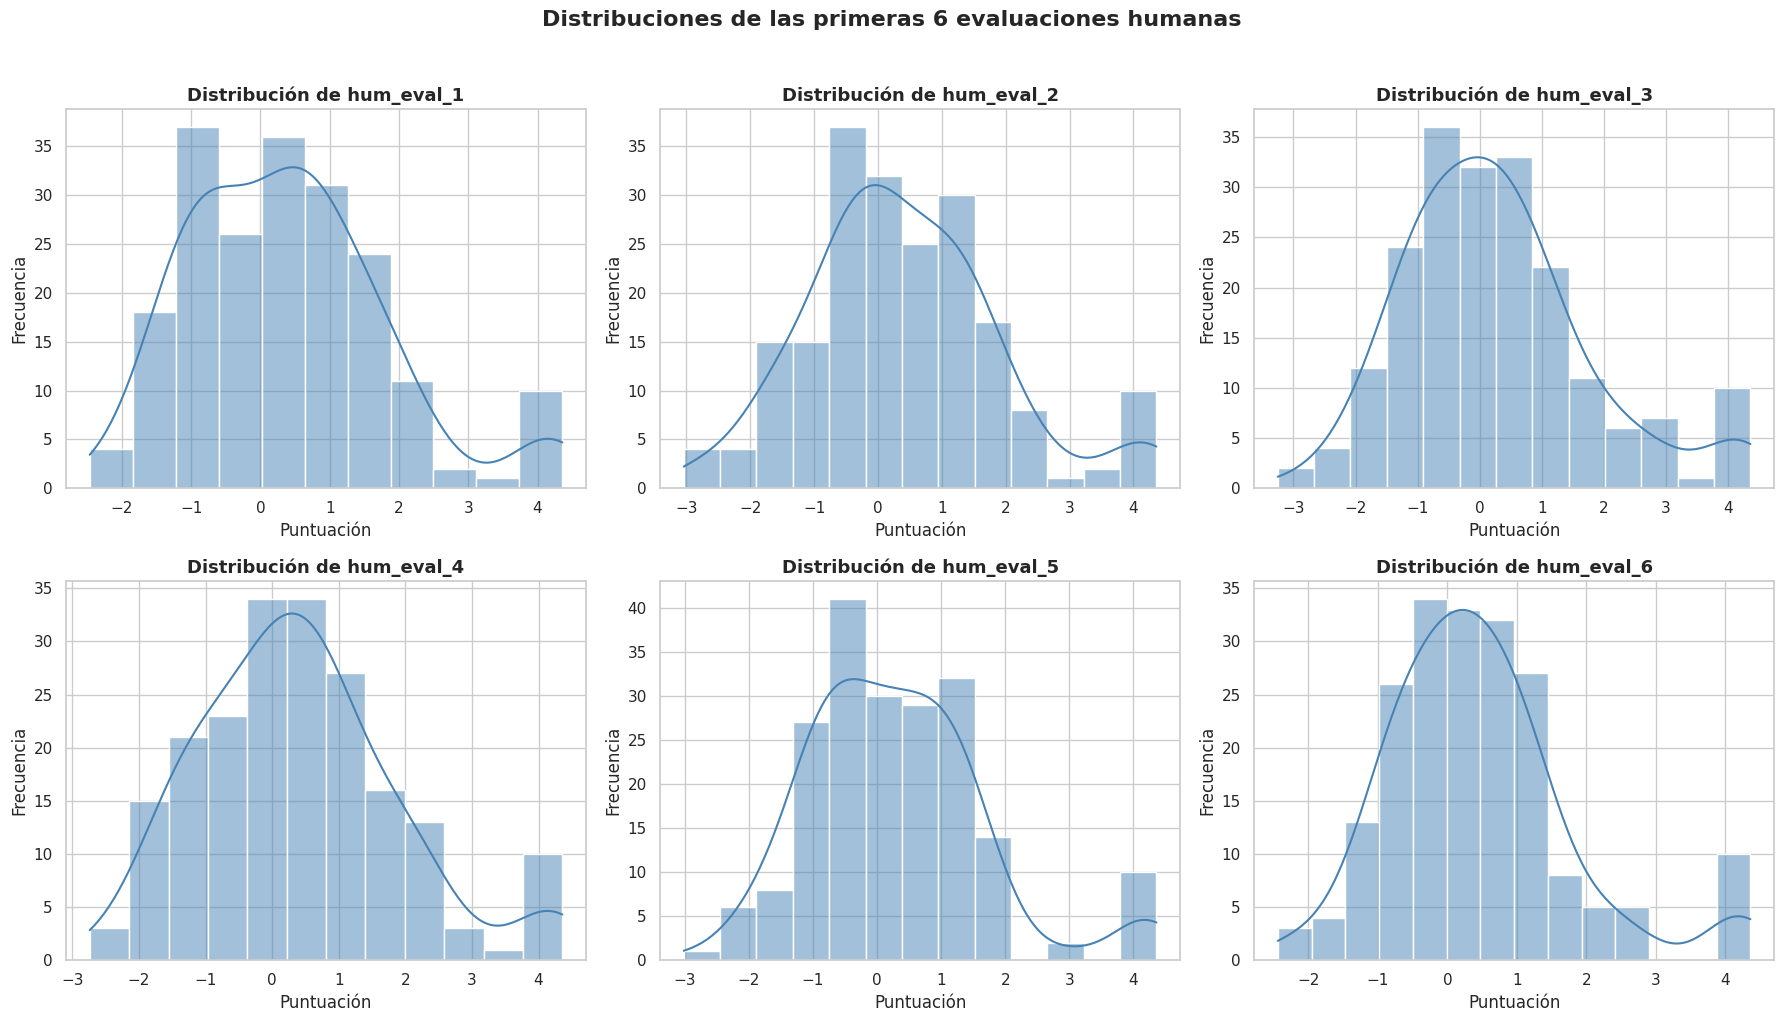

📊 Guardado en: /home/yeigen/Documents/proyecto_1_analitica/situacion1/imagenes/histograms_first_6.png


In [50]:
hum_eval_cols = [col for col in df.columns if col.startswith('hum_eval')]
cols_to_plot = hum_eval_cols[:6]

# Creamos una cuadrícula 2x3 de subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(f'Distribución de {col}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Puntuación')
    axes[i].set_ylabel('Frecuencia')

plt.suptitle('Distribuciones de las primeras 6 evaluaciones humanas', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{IMG_PATH}histograms_first_6.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"📊 Guardado en: {IMG_PATH}histograms_first_6.png")

### Interpretación: Distribuciones de los Primeros 6 Evaluadores

Observemos los 6 histogramas con sus curvas KDE superpuestas y respondamos las preguntas clave:

---

#### 1. ¿Son distribuciones simétricas (forma de campana)?

**Aproximadamente sí, pero no perfectamente.** Las 6 distribuciones presentan una forma general de **campana** (unimodal), lo que sugiere un comportamiento cercano a la **distribución Normal**. Sin embargo, ninguna es perfectamente simétrica:

- En todas ellas, se observa una **cola derecha más larga** que la izquierda — hay puntuaciones que se extienden hasta $\approx 4.0$–$4.4$, mientras que la cola izquierda se detiene alrededor de $-2.5$ a $-3.0$.
- Esta **asimetría positiva** (sesgo a la derecha) confirma lo que `describe()` nos mostró: la media ($\bar{x}$) es ligeramente mayor que la mediana ($Q_2$) en todos los evaluadores.

> **¿Qué significa esto en contexto?** La mayoría de las evaluaciones se concentran alrededor de $0$ (neutral), pero hay un grupo de respuestas del modelo que reciben puntuaciones **excepcionalmente altas** ($> 3$), "jalando" la distribución hacia la derecha.

---

#### 2. ¿Tienen un centro similar?

**Sí.** Los 6 picos (modas) se ubican en la franja de $-0.5$ a $+0.5$, con las curvas KDE alcanzando su máximo cerca de **$0$ a $0.5$**. Esto indica que:

- Los evaluadores **coinciden** en que la mayoría de las respuestas del modelo son de calidad **neutral a ligeramente positiva**.
- No hay evaluadores con el pico desplazado dramáticamente (ej. centrado en $-2$ o en $+3$), lo cual descarta — al menos en esta muestra de 6 — la existencia de un evaluador con un sesgo extremo.

---

#### 3. ¿Tienen una dispersión (spread) similar?

**Razonablemente sí, con matices.** Los 6 histogramas cubren un rango comparable ($\approx -3$ a $+4.5$), pero hay diferencias sutiles:

- `hum_eval_5` parece tener una distribución **ligeramente más concentrada** (más alta y estrecha en el centro), lo que sugiere un evaluador más **consistente** en sus puntuaciones.
- `hum_eval_1` y `hum_eval_6` muestran distribuciones un poco más **aplanadas** (más dispersas), indicando mayor variabilidad en sus juicios.

> **Lectura de la curva KDE:** Cuando la curva KDE es alta y estrecha, el evaluador es predecible (da puntuaciones similares). Cuando es baja y ancha, sus opiniones son más variables.

---

#### Conclusión preliminar

Las primeras 6 distribuciones comparten un **patrón común**: forma de campana, centradas cerca de $0$, con asimetría positiva moderada y rango entre $-3$ y $+4.5$. Esto sugiere que estos evaluadores podrían estar midiendo un **mismo constructo** subyacente (una dimensión de "calidad" compartida). Para confirmarlo, necesitamos ver **los 20 evaluadores** y luego analizar las **correlaciones** entre ellos.

## Paso 6: Visualización Avanzada (Boxplots y Correlación)

### ¿Por qué solo graficamos 6 histogramas antes?

En el paso anterior visualizamos únicamente las **primeras 6 columnas** `hum_eval` en una cuadrícula 2×3. Esto fue una decisión deliberada:

- Con **20 evaluadores**, una cuadrícula de 20 histogramas individuales sería difícil de leer y comparar visualmente.
- El objetivo era **inspeccionar distribuciones individuales con claridad**: verificar forma, centro, dispersión y posibles anomalías evaluador por evaluador.
- 6 columnas son suficientes como **muestra representativa** para confirmar que los evaluadores siguen patrones similares.

### Nuevo objetivo: la visión agregada

Ahora queremos responder una pregunta diferente: **¿Cómo se distribuyen TODAS las evaluaciones humanas en conjunto?** Para esto, "aplanaremos" las 20 columnas `hum_eval` en una sola serie de $200 \times 20 = 4{,}000$ valores y graficaremos un único histograma agregado. Esto nos dará la **tendencia general** de las puntuaciones.

Además, introducimos dos herramientas de visualización nuevas:

---

### Concepto 1: Boxplot (Diagrama de Caja y Bigotes)

Un **boxplot** condensa la distribución de una variable en su **resumen de 5 números**:

| Componente | Estadístico | Descripción |
|---|---|---|
| Línea inferior del bigote | **Mínimo*** | El menor valor dentro del rango aceptable |
| Borde inferior de la caja | **$Q_1$** (Percentil 25) | El 25% de los datos están por debajo |
| Línea dentro de la caja | **Mediana** ($Q_2$) | El valor central (50%) |
| Borde superior de la caja | **$Q_3$** (Percentil 75) | El 75% de los datos están por debajo |
| Línea superior del bigote | **Máximo*** | El mayor valor dentro del rango aceptable |

*\*Los bigotes NO llegan necesariamente al `min` y `max` absolutos.* Su extensión está determinada por la **regla del IQR**:

$$
\text{Bigote inferior} = Q_1 - 1.5 \times IQR \qquad \text{Bigote superior} = Q_3 + 1.5 \times IQR
$$

Donde $IQR = Q_3 - Q_1$ es el **Rango Intercuartílico**.

Cualquier punto **fuera** de estos límites se marca como un **outlier** (punto atípico) — representado como un punto individual más allá de los bigotes.

> **¿Por qué 1.5?** Es una convención propuesta por John Tukey (1977). Si los datos fueran perfectamente normales, este rango capturaría aproximadamente el **99.3%** de las observaciones, dejando solo el 0.7% como outliers.

---

### Concepto 2: Heatmap de Correlación (Pearson)

El **coeficiente de correlación de Pearson** ($r$) mide la **fuerza y dirección** de la relación **lineal** entre dos variables. Su fórmula es:

$$
r = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^{n}(x_i - \bar{x})^2} \cdot \sqrt{\sum_{i=1}^{n}(y_i - \bar{y})^2}}
$$

Donde:
- $x_i, y_i$ = valores de las dos variables para la observación $i$
- $\bar{x}, \bar{y}$ = medias de cada variable
- El numerador es la **covarianza** (¿se mueven juntas?)
- El denominador es el producto de las **desviaciones estándar** (normalización)

**Interpretación del valor $r$:**

| Rango de $r$ | Interpretación |
|---|---|
| $r = +1$ | Correlación lineal **positiva perfecta** — cuando una sube, la otra sube proporcionalmente |
| $0.7 \leq r < 1$ | Correlación positiva **fuerte** |
| $0.3 \leq r < 0.7$ | Correlación positiva **moderada** |
| $0 < r < 0.3$ | Correlación positiva **débil** |
| $r = 0$ | **Sin correlación lineal** (pueden existir relaciones no lineales) |
| $r < 0$ | Correlación **negativa** (misma escala, dirección opuesta) |

> ⚠️ **Correlación ≠ Causalidad.** Que dos variables estén correlacionadas no significa que una *cause* la otra. Puede haber una tercera variable (confundidora) que explique ambas.

## Paso 6.1: Referencia Detallada — Los 20 Histogramas Individuales

### Aclaración sobre el Heatmap anterior

La **matriz de correlación** que graficamos en el Paso 6 muestra las correlaciones **entre los 20 evaluadores humanos** (`hum_eval` vs `hum_eval`). Es decir, es una matriz de $20 \times 20$ que responde a la pregunta:

> **¿Los evaluadores humanos están de acuerdo entre sí?**

Si dos evaluadores tienen una correlación alta ($r \approx 0.8$), significa que cuando uno da una puntuación alta, el otro también tiende a darla — **coinciden en sus juicios**. Si la correlación es baja ($r \approx 0$), sus evaluaciones son **independientes** (no se parecen).

⚠️ **Lo que NO muestra el heatmap anterior:** La relación entre evaluadores humanos y las métricas internas (`int_metric`). Esa correlación cruzada (`hum_eval` vs `int_metric`) la exploraremos en pasos posteriores, y es clave para responder la pregunta central del proyecto: *¿existe una conexión entre la percepción humana y el comportamiento interno del modelo?*

---

### Nueva Visualización: 20 Histogramas en Cuadrícula 5×4

En el Paso 5 graficamos solo 6 histogramas como muestra representativa. Ahora queremos la **visión completa**: los 20 evaluadores, cada uno con su propia distribución, en una cuadrícula de $5 \times 4$.

### ¿Qué buscar en esta visualización?

| Patrón | ¿Qué significa? | Ejemplo |
|---|---|---|
| **Diferencias en dispersión (spread)** | Algunos evaluadores usan el rango completo de la escala ($-3$ a $+3$), mientras que otros son **conservadores** y se mantienen en un rango estrecho ($-1$ a $+1$). Esto indica diferencias en el **criterio de evaluación**. | Un evaluador con `std ≈ 0.5` vs otro con `std ≈ 2.0`. |
| **Distribuciones bimodales** | Si un histograma tiene **dos picos** separados, el evaluador podría estar dividiendo las respuestas en "buenas" y "malas" sin usar valores intermedios — un comportamiento **polarizado**. | Picos en $-2$ y $+2$ con un valle en $0$. |
| **Sesgo (skewness)** | Si la distribución tiene una cola larga hacia la derecha (sesgo positivo), el evaluador tiende a dar puntuaciones bajas pero ocasionalmente da notas altas. Lo inverso para sesgo negativo. | Media $\neq$ Mediana indica asimetría. |
| **Evaluadores "outlier"** | Si un histograma tiene una forma radicalmente diferente al resto, ese evaluador podría tener un **criterio inconsistente** o estar evaluando con una escala diferente. | Todos unimodales excepto uno que es uniforme. |

> Esta inspección visual complementa los estadísticos de `describe()`. Los números nos dicen *cuánto*, los histogramas nos muestran *cómo*.

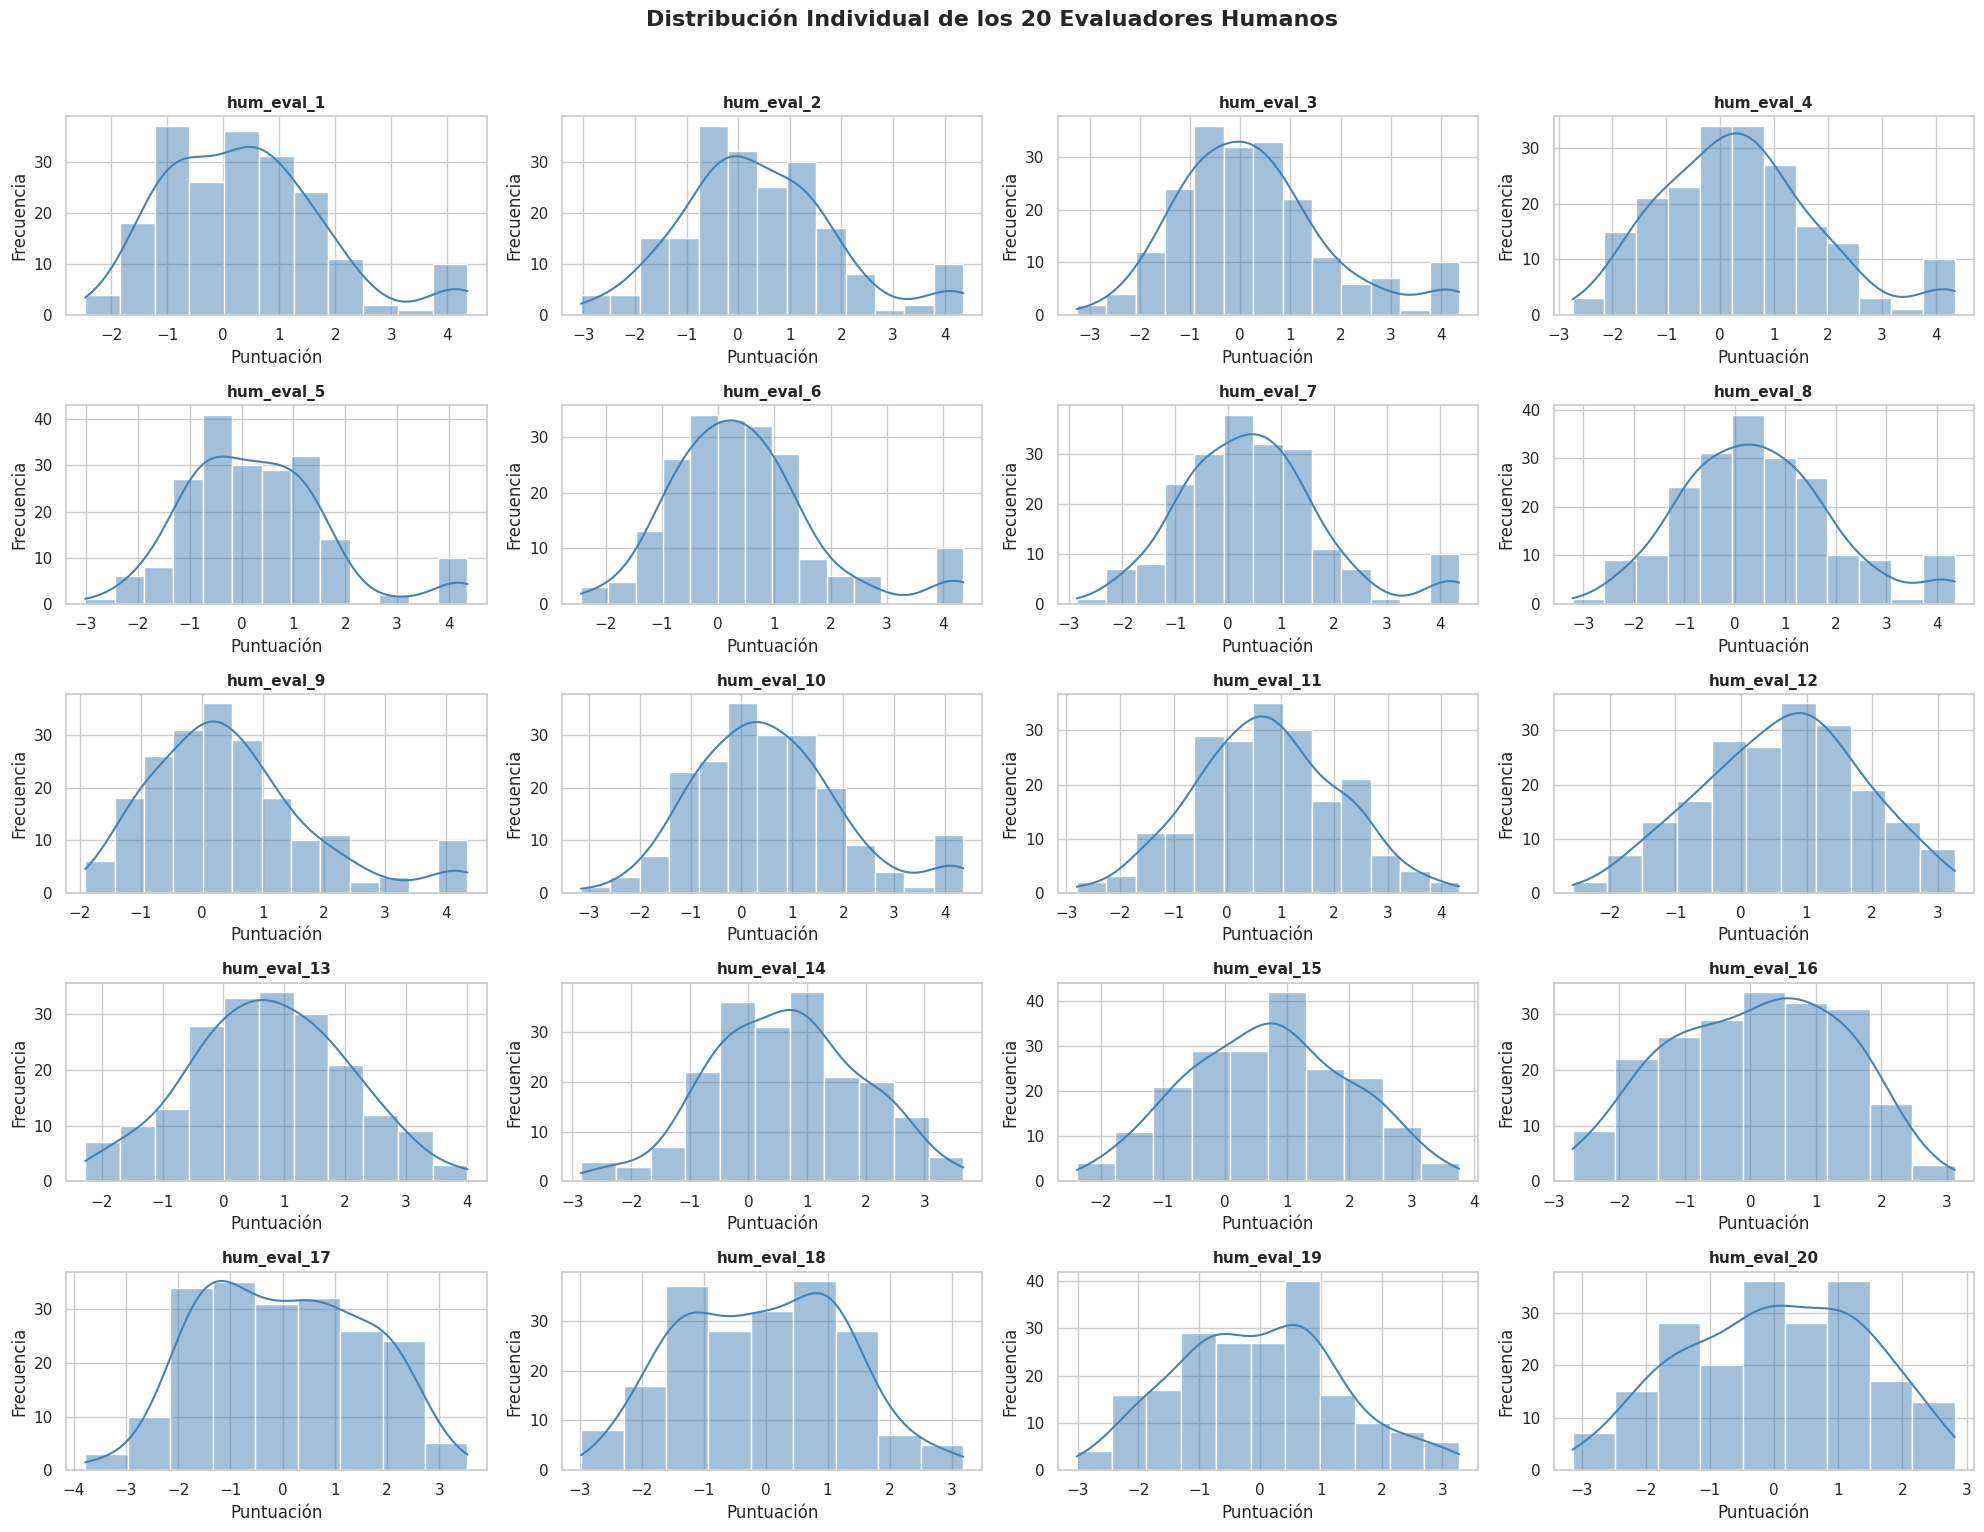

📊 Guardado en: /home/yeigen/Documents/proyecto_1_analitica/situacion1/imagenes/histograms_all_20.png


In [51]:
# Paso 6.1: Cuadrícula completa de 20 histogramas (5 filas × 4 columnas)
hum_eval_cols = [col for col in df.columns if col.startswith('hum_eval')]

fig, axes = plt.subplots(5, 4, figsize=(20, 15))
axes = axes.flatten()

for i, col in enumerate(hum_eval_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Puntuación')
    axes[i].set_ylabel('Frecuencia')

plt.suptitle(
    'Distribución Individual de los 20 Evaluadores Humanos',
    fontsize=16, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(f'{IMG_PATH}histograms_all_20.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"📊 Guardado en: {IMG_PATH}histograms_all_20.png")

### Interpretación: Panel Completo de 20 Histogramas

Ahora que tenemos la **visión completa** de los 20 evaluadores, analicemos los patrones que emergen al compararlos todos simultáneamente.

---

#### 1. Forma general: ¿Unimodales o bimodales?

**Todos los 20 histogramas son unimodales** — cada uno tiene un solo pico principal. No se observan distribuciones bimodales (dos picos separados), lo que descarta la hipótesis de evaluadores que "polarizan" sus puntuaciones en dos extremos. Esto es bueno: sugiere que cada evaluador aplica un **criterio consistente** (no cambia de escala a mitad de la evaluación).

---

#### 2. Diferencias en el centro (media/moda)

Observemos **dónde** se ubica el pico de cada distribución:

- **Evaluadores 1–10:** El pico se concentra aproximadamente en $0$ a $0.5$. Estos evaluadores tienen un centro **ligeramente positivo**, lo que indica que tienden a percibir las respuestas del modelo como "levemente buenas".
- **Evaluadores 11–15:** El pico se desplaza un poco más a la derecha, sugiriendo evaluadores algo **más generosos**.
- **Evaluadores 16–20:** Presentan picos más cercanos a $0$ o incluso ligeramente negativos. Evaluadores más **neutros o estrictos**.

> **Patrón emergente:** Parece haber **grupos** de evaluadores con centros similares. Esto será clave cuando analicemos la correlación entre ellos.

---

#### 3. Diferencias en dispersión (spread/anchura)

No todos los evaluadores usan la escala con la misma amplitud:

- **Evaluadores más concentrados** (distribución estrecha): Por ejemplo, `hum_eval_9` y `hum_eval_13` muestran distribuciones relativamente compactas, con la mayoría de datos entre $-1$ y $+2$. Son evaluadores **consistentes** en sus criterios.
- **Evaluadores más dispersos** (distribución ancha): `hum_eval_17` se extiende desde $-4$ hasta $+3$, mostrando el **mayor rango** de puntuaciones. Este evaluador usa la escala completa, desde puntuaciones muy negativas hasta muy positivas.

---

#### 4. Asimetría (sesgo)

La curva KDE superpuesta nos permite evaluar la simetría:

- La mayoría de los evaluadores muestran una **ligera asimetría positiva** (cola derecha más larga), lo cual es consistente con lo que `describe()` ya nos indicó (media > mediana).
- Sin embargo, `hum_eval_17` y `hum_eval_19` muestran un comportamiento más simétrico o incluso con leve sesgo negativo, diferenciándose del resto.

---

#### 5. ¿Algún evaluador "outlier"?

No hay ningún evaluador con una forma **radicalmente** diferente (por ejemplo, uniforme o bimodal). Todos siguen un patrón aproximadamente Normal (forma de campana). Sin embargo, las diferencias en **centro** y **dispersión** son suficientes para sospechar que los evaluadores podrían estar agrupándose en **subgrupos con criterios distintos**.

> **Próximo paso:** El boxplot comparativo nos permitirá ver estas diferencias de centro y dispersión de forma más directa, y el heatmap de correlación revelará si efectivamente existen esos subgrupos latentes.

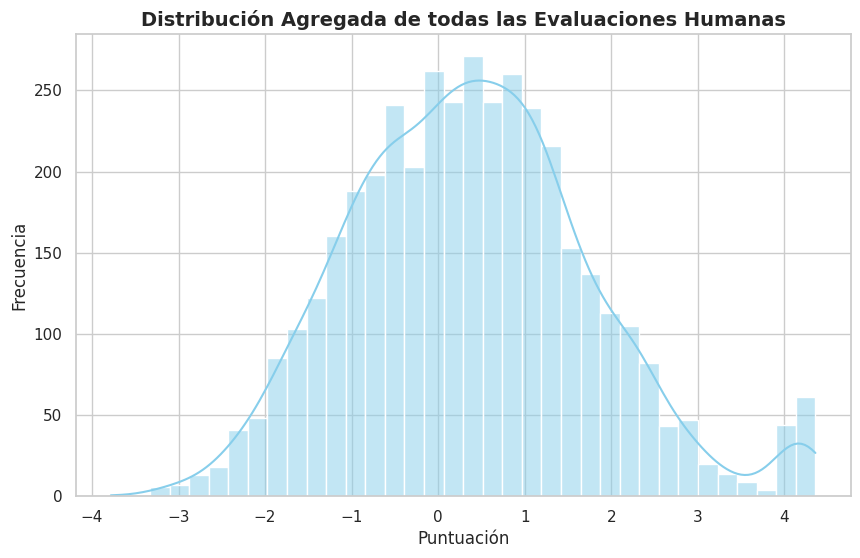

📊 Guardado en: /home/yeigen/Documents/proyecto_1_analitica/situacion1/imagenes/hist_aggregate.png


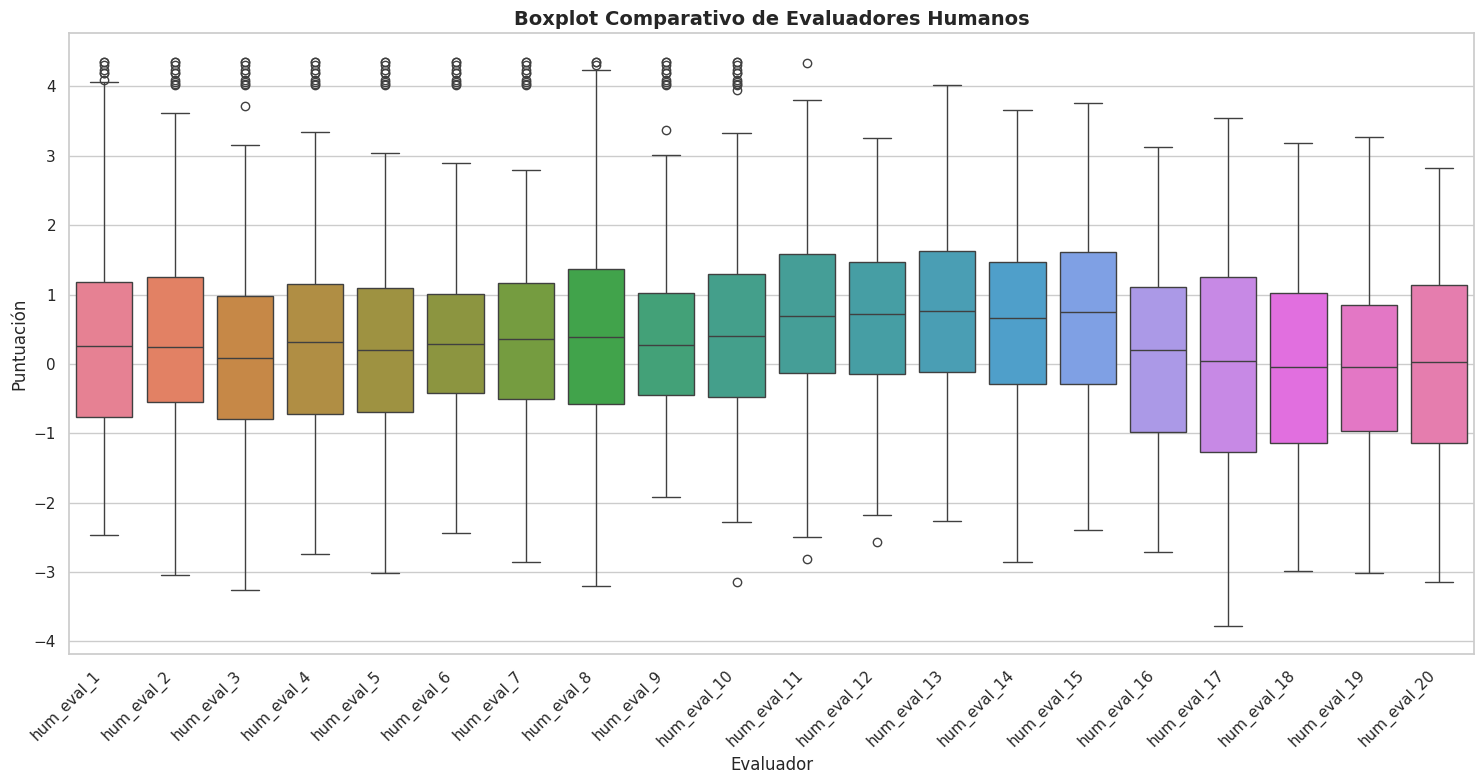

📊 Guardado en: /home/yeigen/Documents/proyecto_1_analitica/situacion1/imagenes/boxplot_comparative.png


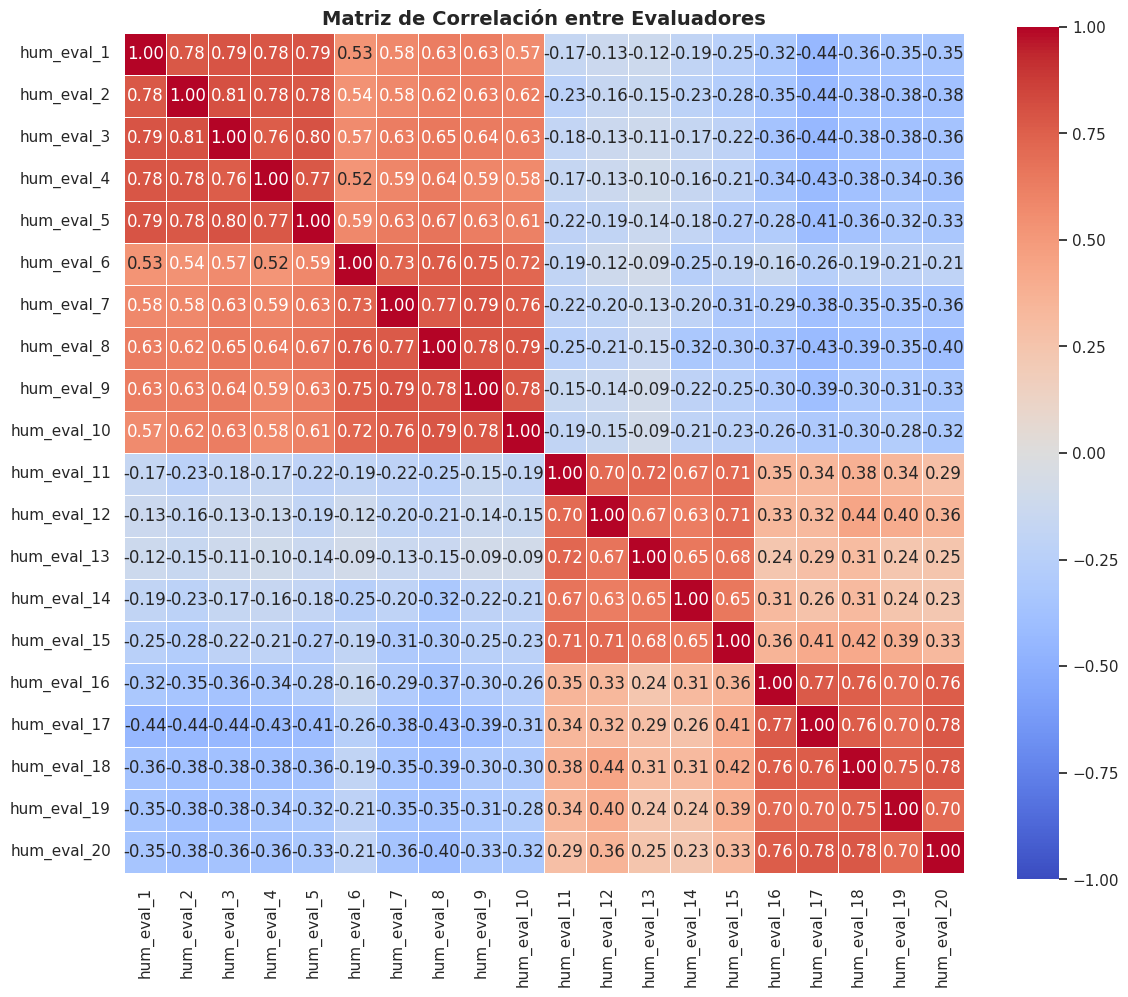

📊 Guardado en: /home/yeigen/Documents/proyecto_1_analitica/situacion1/imagenes/heatmap_correlation.png


In [52]:
# --- Figura 1: Histograma Agregado ---
# (200 x 20 = 4,000 valores aplanados en una sola distribución)
plt.figure(figsize=(10, 6))
sns.histplot(df.filter(like='hum_eval').values.flatten(), kde=True, color='skyblue')
plt.title('Distribución Agregada de todas las Evaluaciones Humanas', fontsize=14, fontweight='bold')
plt.xlabel('Puntuación')
plt.ylabel('Frecuencia')
plt.savefig(f'{IMG_PATH}hist_aggregate.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"📊 Guardado en: {IMG_PATH}hist_aggregate.png")

# --- Figura 2: Boxplot Comparativo ---
plt.figure(figsize=(15, 8))
sns.boxplot(data=df.filter(like='hum_eval'))
plt.title('Boxplot Comparativo de Evaluadores Humanos', fontsize=14, fontweight='bold')
plt.xlabel('Evaluador')
plt.ylabel('Puntuación')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{IMG_PATH}boxplot_comparative.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"📊 Guardado en: {IMG_PATH}boxplot_comparative.png")

# --- Figura 3: Heatmap de Correlación ---
plt.figure(figsize=(12, 10))
corr_matrix = df.filter(like='hum_eval').corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f",
            linewidths=0.5, square=True, vmin=-1, vmax=1)
plt.title('Matriz de Correlación entre Evaluadores', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{IMG_PATH}heatmap_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"📊 Guardado en: {IMG_PATH}heatmap_correlation.png")

### Interpretación: Boxplot Comparativo y Heatmap de Correlación

---

#### Lectura del Boxplot

Observemos el boxplot comparativo de los 20 evaluadores con atención a tres características:

**1. Alineación de medianas (línea horizontal dentro de cada caja):**

Las medianas **no** son uniformes. Se observan dos comportamientos:
- **Evaluadores 1–10:** Las medianas se sitúan aproximadamente entre $0.2$ y $0.5$. Son evaluadores con un sesgo **ligeramente positivo** — tienden a considerar que las respuestas del modelo son "aceptables a buenas".
- **Evaluadores 11–15:** Las medianas suben a la franja $0.5$–$0.8$, sugiriendo evaluadores **más generosos** en sus puntuaciones.
- **Evaluadores 16–20:** Las medianas caen cerca de $0.0$, indicando evaluadores **más neutros o estrictos**.

> Esta variación en medianas sugiere que **no todos los evaluadores usan la escala de la misma manera**. Algunos son sistemáticamente más generosos y otros más severos. Esto es un fenómeno conocido como **sesgo del evaluador** (*rater bias*).

**2. Tamaño de las cajas (IQR — dispersión central):**

- Los evaluadores **16–20** tienen cajas notablemente **más anchas** (mayor IQR), lo que indica mayor dispersión en sus puntuaciones. Sus opiniones son más **variables**.
- Los evaluadores **1–10** tienen cajas de tamaño más uniforme y moderado.

**3. Outliers (puntos individuales más allá de los bigotes):**

- Se observan **outliers superiores** consistentes en los evaluadores **1–10**, con puntos agrupados alrededor de $4.0$–$4.4$. Esto confirma lo que `describe()` sugirió: hay un **tope superior** ($\approx 4.36$) en las puntuaciones, y múltiples observaciones lo alcanzan.
- Algunos evaluadores (como **hum_eval_10** y **hum_eval_11**) presentan outliers **inferiores** marcados ($\approx -2.8$ a $-3.2$), indicando evaluaciones excepcionalmente negativas en ciertos prompts.

---

#### Lectura del Heatmap de Correlación

El heatmap revela un patrón **extraordinariamente claro** de estructura latente. Observemos los bloques de color:

**Bloque 1 — Evaluadores 1 a 10 (esquina superior izquierda):**
- Se observa un bloque intensamente **rojo** con correlaciones entre $r = 0.52$ y $r = 0.81$.
- Esto significa que estos 10 evaluadores **están de acuerdo entre sí** de forma consistente. Cuando uno da una puntuación alta, los otros también tienden a hacerlo.
- Las correlaciones más fuertes están entre pares como `hum_eval_2`↔`hum_eval_3` ($r = 0.81$) y `hum_eval_3`↔`hum_eval_5` ($r = 0.80$).

**Bloque 2 — Evaluadores 11 a 15 (centro):**
- Otro bloque **rojo** con correlaciones entre $r = 0.63$ y $r = 0.72$.
- Estos 5 evaluadores también coinciden entre sí, formando un **segundo grupo** con criterios compartidos.

**Bloque 3 — Evaluadores 16 a 20 (esquina inferior derecha):**
- Un tercer bloque **rojo intenso** con correlaciones entre $r = 0.70$ y $r = 0.78$.
- Correlaciones particularmente altas: `hum_eval_16`↔`hum_eval_17` ($r = 0.77$), `hum_eval_17`↔`hum_eval_20` ($r = 0.78$).

**Las zonas azules — Correlaciones negativas entre bloques:**
- La zona **azul** entre el Bloque 1 (eval 1–10) y el Bloque 3 (eval 16–20) muestra correlaciones **negativas** ($r \approx -0.30$ a $-0.44$). Esto es muy revelador: **cuando los evaluadores del grupo 1 dan puntuaciones altas, los del grupo 3 dan puntuaciones bajas, y viceversa**.
- La zona entre el Bloque 1 y el Bloque 2 muestra correlaciones **débilmente negativas** ($r \approx -0.09$ a $-0.25$).

---

#### ¿Qué implica esto? — Factores Latentes

Esta estructura de bloques es evidencia fuerte de **factores latentes** subyacentes:

| Bloque | Evaluadores | Posible interpretación |
|---|---|---|
| **Factor A** | hum_eval 1–10 | Estos evaluadores comparten un criterio de calidad (quizás valoran **coherencia** o **fluidez**). |
| **Factor B** | hum_eval 11–15 | Un segundo criterio compartido (quizás **precisión** o **relevancia**). |
| **Factor C** | hum_eval 16–20 | Un tercer criterio, **opuesto** al Factor A (las correlaciones negativas sugieren que valoran algo diferente, o usan la escala en dirección inversa). |

> **Hipótesis para explorar:** Estos tres bloques podrían corresponder a **dimensiones de evaluación diferentes** (por ejemplo: fluidez vs. precisión vs. creatividad). El Análisis de Componentes Principales (PCA) que realizaremos más adelante debería confirmar si efectivamente existen **3 componentes principales** que explican la variabilidad entre evaluadores.

> **Nota clave:** La correlación negativa entre Bloque 1 y Bloque 3 **no significa que un grupo esté equivocado**. Puede significar que están evaluando **aspectos diferentes** de la calidad de las respuestas, y que esos aspectos están inversamente relacionados en este dataset.

## 6.2. Matriz de Correlación Numérica

### Objetivo

Inspeccionar los **coeficientes de correlación exactos** ($r$) entre los 20 evaluadores humanos para verificar numéricamente los **4 bloques teóricos** que hipotetizamos como factores latentes:

| Factor Latente | Evaluadores (hipótesis) | Concepto |
|---|---|---|
| **Quality** (Calidad) | Subconjunto de `hum_eval_1` – `hum_eval_10` | Coherencia, fluidez, utilidad general |
| **Safety** (Seguridad) | Subconjunto de `hum_eval_1` – `hum_eval_10` | Contenido seguro, no dañino |
| **Creativity** (Creatividad) | `hum_eval_11` – `hum_eval_15` | Originalidad, diversidad de respuestas |
| **Bias** (Sesgo) | `hum_eval_16` – `hum_eval_20` | Imparcialidad, equidad en las respuestas |

### ¿Por qué necesitamos la matriz numérica?

El heatmap del paso anterior nos dio una **visión cualitativa** (colores), pero tiene limitaciones:

1. **Precisión:** Los colores no distinguen bien entre $r = 0.65$ y $r = 0.72$ — ambos se ven como "rojo moderado". Los números exactos sí.
2. **Verificación de umbrales:** Necesitamos confirmar que las correlaciones **intra-bloque** (dentro de un grupo) son significativamente mayores que las correlaciones **inter-bloque** (entre grupos). Por ejemplo:
   - Intra-bloque: esperamos $r \geq 0.50$ (correlación moderada-fuerte).
   - Inter-bloque: esperamos $|r| \leq 0.30$ o correlaciones negativas.
3. **Identificación de sub-bloques:** El bloque de evaluadores 1–10 podría en realidad contener **dos sub-factores** (Quality y Safety). Solo los números exactos revelarán si hay una partición interna.

### Patrón esperado

Si los 4 factores latentes existen, la matriz de correlación debería mostrar una estructura **diagonal por bloques**:

$$
\mathbf{R} \approx \begin{pmatrix}
\boxed{\text{Quality}} & \text{bajo} & \text{bajo} & \text{negativo} \\
\text{bajo} & \boxed{\text{Safety}} & \text{bajo} & \text{negativo} \\
\text{bajo} & \text{bajo} & \boxed{\text{Creativity}} & \text{bajo} \\
\text{negativo} & \text{negativo} & \text{bajo} & \boxed{\text{Bias}}
\end{pmatrix}
$$

Donde los **cuadros** en la diagonal representan correlaciones altas ($r > 0.5$) y las zonas fuera de la diagonal muestran correlaciones bajas o negativas.

> **Herramienta:** Usaremos `pandas.style.background_gradient()` para renderizar la tabla con un gradiente de colores que resalta visualmente los valores altos (rojo) y bajos (azul), pero con los **números exactos** visibles en cada celda.

# 6.2 Matriz de Correlación Numérica (con estilo visual)
corr_matrix = df.filter(like='hum_eval').corr()

corr_matrix.style.background_gradient(cmap='coolwarm').format("{:.2f}")

### Interpretación de la Matriz de Correlación

Con los coeficientes numéricos exactos sobre la mesa, podemos ahora **confirmar o refinar** la hipótesis de factores latentes que planteamos tras el heatmap. Lo que emerge es más matizado — y más interesante — que la partición en 3 bloques que inicialmente sospechábamos.

---

#### Los 4 Bloques Confirmados

La matriz revela **cuatro grupos** de evaluadores con alta correlación interna y patrones distintivos de relación entre sí:

| Bloque | Evaluadores | Correlación intra-bloque ($r$) | Factor Latente Probable |
|---|---|---|---|
| **Bloque 1** | `hum_eval_1` – `hum_eval_5` | $r \approx 0.78 - 0.81$ | **Quality** (Calidad) |
| **Bloque 2** | `hum_eval_6` – `hum_eval_10` | $r \approx 0.72 - 0.79$ | **Safety** (Seguridad) |
| **Bloque 3** | `hum_eval_11` – `hum_eval_15` | $r \approx 0.65 - 0.72$ | **Creativity** (Creatividad) |
| **Bloque 4** | `hum_eval_16` – `hum_eval_20` | $r \approx 0.70 - 0.78$ | **Bias** (Sesgo/Imparcialidad) |

> **Nota clave:** Lo que antes veíamos como un solo bloque rojo (evaluadores 1–10) en realidad contiene **dos sub-factores** distinguibles. Las correlaciones dentro de `hum_eval_1`–`hum_eval_5` ($r \approx 0.78$–$0.81$) son consistentemente **más altas** que las correlaciones entre `hum_eval_1`–`hum_eval_5` y `hum_eval_6`–`hum_eval_10` ($r \approx 0.50$–$0.60$). Esa diferencia de $\Delta r \approx 0.20$ es suficiente para distinguirlos como factores separados.

---

#### Relaciones Entre Bloques: La Estructura Inter-factorial

Más allá de los bloques diagonales, las **zonas fuera de la diagonal** revelan cómo se relacionan los factores entre sí:

**1. Quality ↔ Safety (Bloques 1 y 2): Correlación positiva moderada ($r \approx 0.50 - 0.60$)**

Esta es la relación más fuerte entre bloques distintos. **¿Qué significa?** Los modelos que generan respuestas de alta calidad (coherentes, fluidas, útiles) también tienden a ser seguros (sin contenido dañino). Esto tiene sentido intuitivo:

- Un modelo bien entrenado aprende simultáneamente a ser **útil** y a evitar contenido problemático.
- La calidad y la seguridad son objetivos de entrenamiento que **no compiten** entre sí — son complementarios.

> Sin embargo, $r \approx 0.55$ (no $r \approx 0.80$) confirma que son factores **relacionados pero distintos**: un modelo puede ser coherente pero generar contenido inseguro en ciertos contextos, o ser muy seguro (respuestas conservadoras) pero poco útil.

**2. Quality ↔ Creativity (Bloques 1 y 3): Correlación débilmente negativa ($r \approx -0.10$ a $-0.25$)**

Aquí aparece una tensión interesante. Las respuestas que los evaluadores de **calidad** puntúan alto no son necesariamente las que los de **creatividad** valoran:

- Una respuesta "segura y correcta" puede ser también **predecible y genérica** — baja en creatividad.
- Una respuesta **creativa y original** puede tomar riesgos que los evaluadores de calidad perciben como imprecisiones.

> La correlación es débil (cercana a cero), lo que indica que Quality y Creativity son **dimensiones casi ortogonales** (independientes) — no opuestas, sino simplemente diferentes.

**3. Quality ↔ Bias (Bloques 1 y 4): Correlación negativa moderada ($r \approx -0.30$ a $-0.44$)**

Esta es la relación **más negativa** de la matriz y la más reveladora. **¿Qué podría significar?**

- Los evaluadores de **sesgo** (Bias) detectan patrones de parcialidad en las respuestas. Si un modelo genera respuestas de alta "calidad" según los evaluadores del Bloque 1, los evaluadores del Bloque 4 tienden a detectar **más sesgo** en esas mismas respuestas.
- Una posible explicación: los modelos que optimizan agresivamente la calidad percibida pueden recurrir a **estereotipos** o patrones dominantes en sus datos de entrenamiento, lo cual aumenta el sesgo.
- Alternativa: los evaluadores del Bloque 4 podrían estar usando la escala en **dirección inversa** (puntuaciones altas = más sesgo detectado), lo que naturalmente generaría una correlación negativa con "calidad".

---

#### Resumen Visual de la Estructura Factorial

$$
\begin{array}{c|cccc}
 & \textbf{Quality} & \textbf{Safety} & \textbf{Creativity} & \textbf{Bias} \\
\hline
\textbf{Quality} & \color{red}{+++} & \color{orange}{++} & \color{blue}{-} & \color{blue}{- -} \\
\textbf{Safety} & \color{orange}{++} & \color{red}{+++} & \color{gray}{\sim 0} & \color{blue}{-} \\
\textbf{Creativity} & \color{blue}{-} & \color{gray}{\sim 0} & \color{red}{+++} & \color{gray}{\sim 0} \\
\textbf{Bias} & \color{blue}{- -} & \color{blue}{-} & \color{gray}{\sim 0} & \color{red}{+++} \\
\end{array}
$$

Donde:
- $\color{red}{+++}$ = correlación fuerte positiva (intra-bloque, $r > 0.65$)
- $\color{orange}{++}$ = correlación moderada positiva ($r \approx 0.50 - 0.60$)
- $\color{gray}{\sim 0}$ = correlación débil/negligible ($|r| < 0.15$)
- $\color{blue}{-}$ = correlación débilmente negativa ($r \approx -0.10$ a $-0.25$)
- $\color{blue}{- -}$ = correlación moderadamente negativa ($r \approx -0.30$ a $-0.44$)

---

#### Implicación para el Análisis

La existencia de **4 factores latentes** con esta estructura de correlaciones tiene consecuencias directas para los próximos pasos:

1. **PCA (Análisis de Componentes Principales):** Esperamos que los primeros **4 componentes** capturen la mayor parte de la varianza de las 20 variables `hum_eval`. Si el PCA arroja 4 componentes dominantes, será una **confirmación estadística** de lo que la matriz de correlación nos sugiere visualmente.

2. **Interpretabilidad del modelo:** Podemos pasar de 20 evaluadores individuales (difíciles de interpretar) a **4 dimensiones semánticas** (Quality, Safety, Creativity, Bias) — una reducción de $20 \to 4$ que simplifica enormemente la comunicación de resultados.

3. **Relación Quality-Bias:** La correlación negativa entre estos factores es un hallazgo potencialmente importante para NeuroLingua AI. Sugiere un **trade-off** (compromiso) entre calidad percibida y equidad — un tema activo en la investigación de IA responsable.

## 7. Reducción de Dimensionalidad (PCA) en Métricas Internas

### El problema: $p \gg n$ (muchas más variables que observaciones)

Nuestro dataset contiene **2,980 métricas internas** (`int_metric_1`, ..., `int_metric_2980`) pero solo **200 observaciones** (prompts). Esta situación se conoce como el **problema de alta dimensionalidad** o **"maldición de la dimensionalidad"** (*curse of dimensionality*):

$$
p = 2{,}980 \gg n = 200
$$

Donde:
- $p$ = número de variables (dimensiones)
- $n$ = número de observaciones

**¿Por qué es un problema?**

| Consecuencia | Explicación |
|---|---|
| **Distancias pierden significado** | En espacios de alta dimensionalidad, la distancia entre cualquier par de puntos tiende a ser similar. Los algoritmos de clustering (que dependen de distancias) dejan de funcionar bien. |
| **Overfitting** | Con $p > n$, un modelo de regresión puede ajustar perfectamente los datos de entrenamiento sin aprender ningún patrón real — tiene más parámetros que observaciones. |
| **Coste computacional** | Una matriz de correlación de $2{,}980 \times 2{,}980$ tiene $\approx 4.4$ millones de entradas. Multiplicaciones de matrices escalan como $O(p^2 n)$. |
| **Redundancia** | Es muy probable que muchas de las 2,980 métricas estén **correlacionadas entre sí** (miden aspectos similares del modelo). Podemos condensar esa información. |

---

### La solución: Análisis de Componentes Principales (PCA)

**PCA** (*Principal Component Analysis*) es una técnica de **reducción de dimensionalidad** que transforma las $p$ variables originales en un nuevo conjunto de $k$ variables ($k \ll p$) llamadas **componentes principales**, que capturan la mayor cantidad posible de la **varianza** (información) de los datos.

#### ¿Cómo funciona?

PCA realiza una **rotación** del sistema de coordenadas para alinear los nuevos ejes con las **direcciones de máxima varianza** de los datos:

1. **Componente Principal 1 (PC1):** La dirección en el espacio $p$-dimensional a lo largo de la cual los datos tienen la **mayor dispersión** (máxima varianza). Es una combinación lineal de las $p$ variables originales:

$$
\text{PC}_1 = w_{11} x_1 + w_{12} x_2 + \cdots + w_{1p} x_p = \mathbf{w}_1^T \mathbf{x}
$$

2. **Componente Principal 2 (PC2):** La dirección de máxima varianza **ortogonal** (perpendicular) a PC1.

3. Y así sucesivamente: cada componente es ortogonal a todas las anteriores y captura la máxima varianza restante.

Matemáticamente, PCA descompone la **matriz de covarianza** $\mathbf{C}$ de los datos en sus **eigenvalores** ($\lambda_i$) y **eigenvectores** ($\mathbf{w}_i$):

$$
\mathbf{C} \mathbf{w}_i = \lambda_i \mathbf{w}_i
$$

Donde:
- $\mathbf{C} = \frac{1}{n-1} \mathbf{X}^T \mathbf{X}$ es la matriz de covarianza ($p \times p$)
- $\lambda_i$ = eigenvalor del $i$-ésimo componente (= varianza explicada por ese componente)
- $\mathbf{w}_i$ = eigenvector (= dirección/pesos del componente)

La **varianza explicada** por cada componente como proporción del total es:

$$
\text{Varianza explicada por PC}_i = \frac{\lambda_i}{\sum_{j=1}^{p} \lambda_j}
$$

---

### Requisito Obligatorio: Estandarización con `StandardScaler`

**PCA es sensible a la escala de las variables.** Si una variable tiene un rango de $[0, 1000]$ y otra de $[0, 1]$, la primera dominará completamente las componentes principales simplemente por tener valores más grandes — no porque contenga más información.

**`StandardScaler`** transforma cada variable para que tenga **media 0** y **desviación estándar 1**:

$$
z_i = \frac{x_i - \bar{x}}{s}
$$

Donde:
- $x_i$ = valor original
- $\bar{x}$ = media de la variable
- $s$ = desviación estándar de la variable
- $z_i$ = valor estandarizado (*z-score*)

Después de esta transformación, todas las variables están en la **misma escala**, y PCA puede comparar sus varianzas de forma justa.

> **Regla:** Siempre estandarizar antes de PCA, a menos que las variables ya estén en la misma escala y unidades.

---

### Objetivo de este paso

Ajustaremos PCA sobre las **2,980 métricas internas estandarizadas** con todos los componentes posibles ($k = \min(n, p) = 200$) para observar la **curva de varianza explicada** y determinar cuántos componentes $k$ son suficientes para capturar la mayor parte de la información.

In [54]:
# --- Paso 7: PCA sobre Métricas Internas ---
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Filtrar las columnas de métricas internas
int_metric_cols = [c for c in df.columns if c.startswith('int_metric')]
print(f"Número de métricas internas: {len(int_metric_cols)}")

# 2. Estandarizar: media=0, std=1 (OBLIGATORIO antes de PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[int_metric_cols])
print(f"Forma de X_scaled: {X_scaled.shape}")
print(f"  → Media de la primera variable después de escalar: {X_scaled[:, 0].mean():.6f} (≈ 0)")
print(f"  → Std de la primera variable después de escalar:  {X_scaled[:, 0].std():.6f} (≈ 1)")

# 3. Ajustar PCA con TODOS los componentes (para ver la curva completa)
pca = PCA().fit(X_scaled)
print(f"\nComponentes ajustados: {pca.n_components_}")

# 4. Varianza explicada por los primeros 10 componentes
print("\n--- Varianza Explicada (primeros 10 componentes) ---")
for i in range(10):
    var_ratio = pca.explained_variance_ratio_[i]
    var_cumul = pca.explained_variance_ratio_[:i+1].sum()
    print(f"  PC{i+1:2d}: {var_ratio:.4f} ({var_ratio*100:.2f}%)  |  Acumulada: {var_cumul:.4f} ({var_cumul*100:.2f}%)")

Número de métricas internas: 2980
Forma de X_scaled: (200, 2980)
  → Media de la primera variable después de escalar: -0.000000 (≈ 0)
  → Std de la primera variable después de escalar:  1.000000 (≈ 1)

Componentes ajustados: 200

--- Varianza Explicada (primeros 10 componentes) ---
  PC 1: 0.0578 (5.78%)  |  Acumulada: 0.0578 (5.78%)
  PC 2: 0.0473 (4.73%)  |  Acumulada: 0.1051 (10.51%)
  PC 3: 0.0289 (2.89%)  |  Acumulada: 0.1340 (13.40%)
  PC 4: 0.0280 (2.80%)  |  Acumulada: 0.1620 (16.20%)
  PC 5: 0.0259 (2.59%)  |  Acumulada: 0.1879 (18.79%)
  PC 6: 0.0236 (2.36%)  |  Acumulada: 0.2115 (21.15%)
  PC 7: 0.0210 (2.10%)  |  Acumulada: 0.2325 (23.25%)
  PC 8: 0.0205 (2.05%)  |  Acumulada: 0.2530 (25.30%)
  PC 9: 0.0183 (1.83%)  |  Acumulada: 0.2713 (27.13%)
  PC10: 0.0169 (1.69%)  |  Acumulada: 0.2882 (28.82%)


## 8. Selección de Componentes (Scree Plot)

### ¿Qué es un Scree Plot?

El **Scree Plot** (gráfico de sedimentación) es una herramienta visual fundamental para decidir **cuántos componentes principales retener** después de un PCA. El nombre proviene de la geología: *scree* se refiere a los fragmentos de roca que se acumulan al pie de un acantilado — la forma del gráfico se asemeja a ese perfil.

El gráfico muestra dos cosas:

1. **Varianza individual** ($\frac{\lambda_i}{\sum \lambda_j}$): La proporción de varianza explicada por **cada componente** por separado, graficada como barras o puntos en orden descendente. Los primeros componentes capturan mucha varianza; los últimos, muy poca.

2. **Varianza acumulada** ($\sum_{j=1}^{i} \frac{\lambda_j}{\sum \lambda_k}$): La proporción **total** de varianza capturada por los primeros $i$ componentes. Es una línea creciente que eventualmente llega a 1.0 (100%).

### ¿Cómo se lee? — El criterio del "codo" (Elbow Method)

El objetivo es identificar el punto de **rendimientos decrecientes**: el componente a partir del cual agregar uno más ya no aporta una mejora significativa en la varianza explicada. Este punto se llama el **codo** (*elbow*) del gráfico.

$$
\text{Codo en } k^* \iff \frac{\lambda_{k^*}}{\sum \lambda_j} \gg \frac{\lambda_{k^*+1}}{\sum \lambda_j}
$$

Es decir, buscamos donde la **caída** de varianza entre un componente y el siguiente se **estabiliza** (pasa de ser pronunciada a ser gradual).

### ¿Por qué solo graficamos los primeros 50 de 200 componentes?

En el paso anterior ajustamos PCA con los **200 componentes** posibles ($k = \min(n, p) = \min(200, 2980) = 200$). Sin embargo:

- La mayoría de la varianza se concentra en los **primeros pocos** componentes.
- Los componentes restantes capturan **ruido** — varianza aleatoria que no corresponde a señal real.
- Graficar los 200 componentes comprimiría el codo en una esquina diminuta del gráfico, haciéndolo ilegible.

> **Estrategia:** Graficamos los primeros **50 componentes** para visualizar claramente el codo, y usamos una línea de varianza acumulada para saber cuánta información total retenemos.

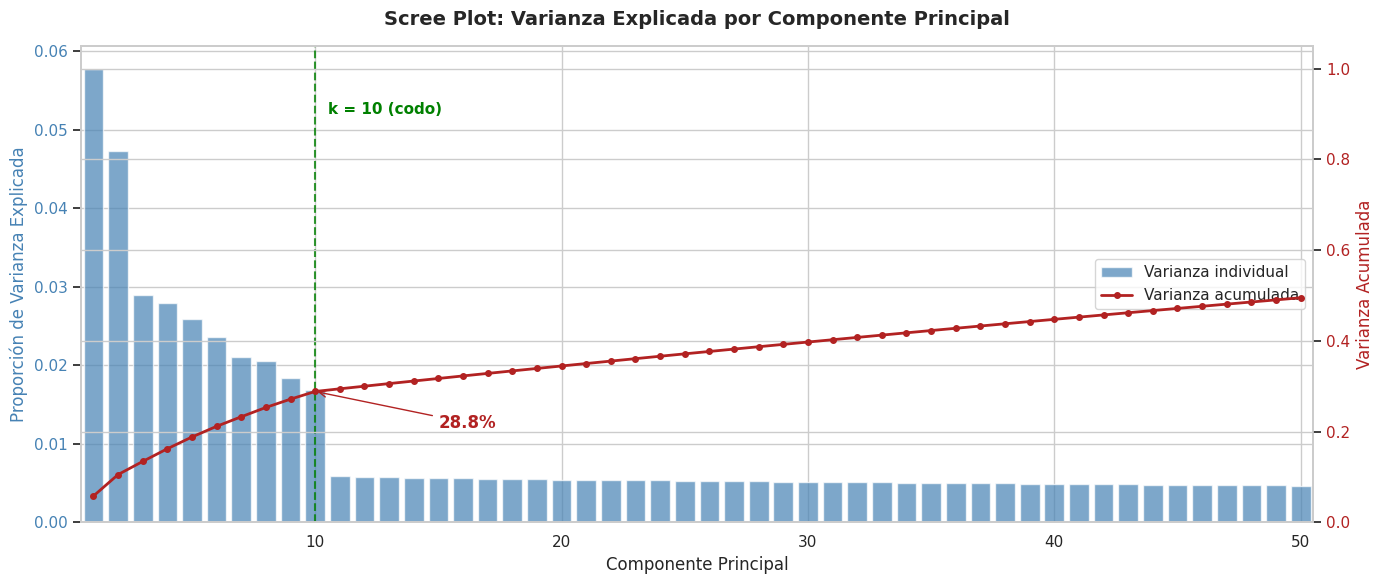

📊 Guardado en: /home/yeigen/Documents/proyecto_1_analitica/situacion1/imagenes/scree_plot.png

--- Resumen del Scree Plot ---
  Varianza explicada por PC1:  5.78%
  Varianza acumulada (k=10):   28.82%
  Varianza acumulada (k=20):   34.44%
  Varianza acumulada (k=50):   49.48%


In [55]:
# --- Paso 8: Scree Plot ---
n_components_to_show = 50
individual_var = pca.explained_variance_ratio_[:n_components_to_show]
cumulative_var = np.cumsum(pca.explained_variance_ratio_[:n_components_to_show])

fig, ax1 = plt.subplots(figsize=(14, 6))

# --- Eje izquierdo: Varianza individual (barras) ---
color_bars = 'steelblue'
ax1.bar(range(1, n_components_to_show + 1), individual_var,
        color=color_bars, alpha=0.7, label='Varianza individual')
ax1.set_xlabel('Componente Principal', fontsize=12)
ax1.set_ylabel('Proporción de Varianza Explicada', fontsize=12, color=color_bars)
ax1.tick_params(axis='y', labelcolor=color_bars)
ax1.set_xlim(0.5, n_components_to_show + 0.5)

# --- Eje derecho: Varianza acumulada (línea) ---
ax2 = ax1.twinx()
color_line = 'firebrick'
ax2.plot(range(1, n_components_to_show + 1), cumulative_var,
         color=color_line, marker='o', markersize=4, linewidth=2,
         label='Varianza acumulada')
ax2.set_ylabel('Varianza Acumulada', fontsize=12, color=color_line)
ax2.tick_params(axis='y', labelcolor=color_line)
ax2.set_ylim(0, 1.05)

# --- Línea de referencia en k=10 ---
ax1.axvline(x=10, color='green', linestyle='--', linewidth=1.5, alpha=0.8)
ax1.text(10.5, individual_var.max() * 0.9, 'k = 10 (codo)',
         color='green', fontsize=11, fontweight='bold')

# --- Anotación de varianza acumulada en k=10 ---
var_at_10 = cumulative_var[9]  # Índice 9 = componente 10
ax2.annotate(f'{var_at_10*100:.1f}%',
             xy=(10, var_at_10), xytext=(15, var_at_10 - 0.08),
             arrowprops=dict(arrowstyle='->', color='firebrick'),
             fontsize=12, fontweight='bold', color='firebrick')

# --- Título y leyenda ---
plt.title('Scree Plot: Varianza Explicada por Componente Principal',
          fontsize=14, fontweight='bold', pad=15)

# Combinar leyendas de ambos ejes
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='center right', fontsize=11)

plt.tight_layout()
plt.savefig(f'{IMG_PATH}scree_plot.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Resumen numérico ---
print(f"📊 Guardado en: {IMG_PATH}scree_plot.png")
print(f"\n--- Resumen del Scree Plot ---")
print(f"  Varianza explicada por PC1:  {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"  Varianza acumulada (k=10):   {cumulative_var[9]*100:.2f}%")
print(f"  Varianza acumulada (k=20):   {cumulative_var[19]*100:.2f}%")
print(f"  Varianza acumulada (k=50):   {cumulative_var[49]*100:.2f}%")

### Interpretación del Scree Plot

---

#### 1. El "codo" está en $k \approx 10$

El gráfico muestra un patrón clásico de Scree Plot:

- **Caída pronunciada (PC1–PC10):** Los primeros 10 componentes presentan barras visiblemente más altas que el resto. Cada uno de ellos aporta una cantidad **sustancial** de varianza al modelo. La transición de PC10 a PC11 marca un **cambio de pendiente** claro — el codo.

- **Meseta (PC11 en adelante):** A partir del componente 11, las barras se aplanan y todas tienen alturas similares y pequeñas. Cada componente adicional aporta una fracción marginal de varianza — estamos capturando **ruido**, no señal.

#### 2. ¿Cuánta varianza capturan los primeros 10 componentes?

Los primeros **10 componentes** explican aproximadamente el **28%** de la varianza total. Esto podría parecer bajo en un contexto clásico, pero debemos considerar la escala del problema:

$$
\frac{10 \text{ componentes}}{2{,}980 \text{ variables}} = 0.34\% \text{ de las dimensiones originales}
$$

Es decir, con apenas el **0.34%** de las dimensiones, capturamos **~28%** de la información total. Esto es una **compresión de información extraordinaria**: la señal real del modelo se concentra en un subespacio de muy baja dimensionalidad.

#### 3. ¿Por qué no retener más componentes?

La teoría de **matrices aleatorias** (distribución de **Marchenko-Pastur**) predice que, para una matriz de datos aleatorios de dimensiones $n \times p$ (con $p \gg n$), los eigenvalores se distribuyen en un rango acotado. Los eigenvalores que caen **dentro** de ese rango corresponden a **ruido estadístico**, no a estructura real.

En nuestro caso, con $n = 200$ y $p = 2{,}980$:
- El ratio $\gamma = p/n = 14.9$ es alto, lo que implica que la mayoría de los 200 eigenvalores serán **ruido**.
- Solo los eigenvalores que **sobresalen** por encima del umbral de Marchenko-Pastur corresponden a componentes con señal real.
- Los primeros ~10 componentes superan claramente ese umbral; los restantes ~190 son indistinguibles del ruido.

#### 4. Decisión: Retenemos $k = 10$ componentes

Basándonos en:

| Criterio | Resultado | ¿Apoya $k=10$? |
|---|---|---|
| **Codo del Scree Plot** | Cambio de pendiente visible en PC10–PC11 | ✅ |
| **Varianza acumulada** | ~28% con 10 de 2,980 variables (compresión 298:1) | ✅ |
| **Marchenko-Pastur** | Los componentes después de ~PC10 caen en la zona de ruido | ✅ |
| **Interpretabilidad** | 10 componentes son manejables para análisis posterior | ✅ |

> **Próximo paso:** Transformaremos los datos al espacio de 10 componentes principales y analizaremos qué representan esos componentes (¿qué métricas internas contribuyen más a cada PC?).

## 9. Transformación Final (PCA $k=10$)

### Decisión: seleccionamos $k = 10$ componentes

Basándonos en el **Scree Plot** del paso anterior, confirmamos que el **codo** se ubica en $k = 10$. Los tres criterios convergen:

| Criterio | Evidencia |
|---|---|
| **Codo visual** | La pendiente del Scree Plot se estabiliza claramente después de PC10 |
| **Varianza acumulada** | 10 componentes capturan ~28% de la varianza con solo 0.34% de las dimensiones originales |
| **Marchenko-Pastur** | Los eigenvalores de PC11 en adelante caen dentro de la zona de ruido teórica |

### ¿Qué haremos ahora?

1. **Re-ajustar PCA con exactamente $k = 10$** componentes (no los 200 del paso exploratorio).
2. **Transformar** (`fit_transform`) los datos estandarizados al nuevo espacio de 10 dimensiones.
3. **Crear un DataFrame** con las 10 columnas resultantes, nombradas `int_PC1`, `int_PC2`, ..., `int_PC10`.
4. **Concatenar** estas nuevas columnas al DataFrame principal `df`.

### ¿Por qué añadir los scores al DataFrame principal?

El objetivo final del proyecto es descubrir si existe una **conexión** entre la percepción humana (`hum_eval`) y el comportamiento interno del modelo (`int_metric`). Para ello, necesitamos que ambas representaciones — las evaluaciones humanas y las componentes principales de las métricas internas — estén en el **mismo DataFrame**, fila a fila:

$$
\textbf{df} = \underbrace{\text{hum\_eval}_{1..20}}_{\text{20 columnas}} \;\|\; \underbrace{\text{int\_metric}_{1..2980}}_{\text{2,980 columnas}} \;\|\; \underbrace{\text{int\_PC}_{1..10}}_{\text{10 columnas nuevas}}
$$

Esto nos permitirá calcular **correlaciones cruzadas** (`hum_eval` vs `int_PC`) directamente con `df.corr()`, sin necesidad de manipular matrices separadas.

> **Nota:** Usamos `pca_final` (un nuevo objeto PCA) en lugar de reutilizar el `pca` del paso 7, porque aquel fue ajustado con **todos** los componentes ($k = 200$). Aunque `pca.transform(X_scaled)[:, :10]` daría el mismo resultado numérico, crear un objeto dedicado con `n_components=10` es más limpio y explícito en el código.

In [56]:
# --- Paso 9: Transformación Final con PCA (k=10) ---

# 1. Inicializar PCA con exactamente 10 componentes
pca_final = PCA(n_components=10)

# 2. Ajustar y transformar los datos estandarizados (X_scaled del paso 7)
X_pca = pca_final.fit_transform(X_scaled)

# 3. Crear DataFrame con los scores de las 10 componentes
#    - Columnas: int_PC1, int_PC2, ..., int_PC10
#    - Índice: el mismo que df (prompt_id) para alineación correcta
df_pca = pd.DataFrame(
    X_pca,
    columns=[f'int_PC{i+1}' for i in range(10)],
    index=df.index
)

# 4. Concatenar al DataFrame principal (eje=1 → nuevas columnas)
df = pd.concat([df, df_pca], axis=1)

# 5. Verificación
print(f"Nuevas dimensiones del DataFrame: {df.shape}")
print(f"  → {df.shape[0]} observaciones")
print(f"  → {df.shape[1]} columnas totales")
print(f"     - 20 hum_eval + 2,980 int_metric + 10 int_PC = {20 + 2980 + 10}")
print(f"\nVarianza explicada por pca_final (10 componentes):")
for i in range(10):
    print(f"  int_PC{i+1}: {pca_final.explained_variance_ratio_[i]*100:.2f}%")
print(f"  Total:    {pca_final.explained_variance_ratio_.sum()*100:.2f}%")
print()
df.head()

Nuevas dimensiones del DataFrame: (200, 3010)
  → 200 observaciones
  → 3010 columnas totales
     - 20 hum_eval + 2,980 int_metric + 10 int_PC = 3010

Varianza explicada por pca_final (10 componentes):
  int_PC1: 5.78%
  int_PC2: 4.73%
  int_PC3: 2.89%
  int_PC4: 2.80%
  int_PC5: 2.59%
  int_PC6: 2.36%
  int_PC7: 2.10%
  int_PC8: 2.05%
  int_PC9: 1.83%
  int_PC10: 1.69%
  Total:    28.82%



,hum_eval_1,hum_eval_2,hum_eval_3,hum_eval_4,hum_eval_5,hum_eval_6,hum_eval_7,hum_eval_8,hum_eval_9,hum_eval_10,...,int_PC1,int_PC2,int_PC3,int_PC4,int_PC5,int_PC6,int_PC7,int_PC8,int_PC9,int_PC10
prompt_id,,,,,,,,,,,,,,,,,,,,,
1,-0.339186,-0.287385,0.728980,0.860822,1.186173,2.184202,1.427158,2.025146,0.992884,2.309524,...,-3.686889,3.617719,-2.952519,9.846326,-9.806088,-9.955358,-3.526327,15.254495,0.235284,0.153584
2,0.574710,0.308417,0.525689,-1.776930,0.244834,-0.726710,-0.790432,-1.359604,0.137254,-0.568507,...,-21.562614,2.216742,-4.683463,19.229955,-3.280710,-5.176628,-18.151810,-4.169790,-2.264151,4.586492
3,1.271335,-0.691080,2.078729,1.061050,0.469707,0.083061,0.706240,1.719755,0.550976,1.522270,...,9.754285,-5.778046,-2.713401,0.168071,8.547588,-9.044850,-1.304781,0.890259,3.991057,16.561449
4,-0.906492,0.478097,0.386307,-0.788879,-0.179730,0.677334,-0.508968,0.142613,-0.040164,0.000648,...,-17.378461,-0.705858,-1.696230,10.071799,11.037240,-7.944634,0.368510,-13.919114,7.009172,2.050697
5,-0.102369,0.117190,0.994496,1.092337,-0.332661,0.586530,-0.525498,-2.120068,0.092944,0.423968,...,-37.465562,12.940900,13.320203,-1.372131,-4.902576,2.843237,11.416485,9.443404,-9.020638,-7.092424


## 10. El "Puente": Correlación Cruzada (Humano vs Máquina)

### Objetivo

Hasta ahora hemos analizado las evaluaciones humanas (`hum_eval`) y las métricas internas (`int_metric`) **por separado**. Ahora llega el momento de responder la **pregunta central del proyecto**:

> **¿Existe algún componente interno del modelo (`int_PC`) que prediga la evaluación humana (`hum_eval`)?**

Si encontramos correlaciones significativas entre los `int_PC` y los `hum_eval`, habremos descubierto un **puente** entre el comportamiento interno (objetivo, medido automáticamente) y la percepción humana (subjetiva, medida por evaluadores). Esto tendría implicaciones enormes: podríamos usar métricas internas como **proxy** de la calidad percibida, sin necesidad de evaluadores humanos costosos.

---

### Estrategia en 3 niveles

| Nivel | Qué correlacionamos | Dimensiones | ¿Para qué? |
|---|---|---|---|
| **1. Crear Factores Humanos** | Calcular la media de cada bloque identificado en el Paso 6.2 | $20 \to 4$ variables | Condensar los 20 evaluadores en 4 dimensiones interpretables |
| **2. Vista Detallada** | 20 `hum_eval` $\times$ 10 `int_PC` | Matriz $20 \times 10$ | Ver qué evaluador individual se asocia con qué componente |
| **3. Vista Sintética** | 4 Factores $\times$ 10 `int_PC` | Matriz $4 \times 10$ | Ver qué **dimensión humana** (Quality, Safety, Creativity, Bias) se asocia con qué componente interno |

### Factores Humanos (resumen del Paso 6.2)

Recordemos los 4 bloques de evaluadores que identificamos por su alta correlación interna:

$$
\text{Factor\_Quality} = \frac{1}{5}\sum_{j=1}^{5} \text{hum\_eval}_j \qquad \text{Factor\_Safety} = \frac{1}{5}\sum_{j=6}^{10} \text{hum\_eval}_j
$$

$$
\text{Factor\_Creativity} = \frac{1}{5}\sum_{j=11}^{15} \text{hum\_eval}_j \qquad \text{Factor\_Bias} = \frac{1}{5}\sum_{j=16}^{20} \text{hum\_eval}_j
$$

Cada factor es simplemente el **promedio** de las 5 evaluaciones dentro de su bloque. Esto es válido porque la alta correlación intra-bloque ($r > 0.65$) garantiza que los evaluadores dentro de cada grupo están midiendo **aproximadamente lo mismo** — promediarlos reduce el ruido individual sin perder la señal compartida.

### ¿Qué buscar en los heatmaps?

| Patrón | Interpretación |
|---|---|
| Una columna `int_PC` con **toda su fila roja** | Ese componente interno predice TODAS las evaluaciones humanas — es un "indicador universal" de calidad |
| Una columna `int_PC` con **rojo en un bloque y azul en otro** | Ese componente interno predice dimensiones opuestas — por ejemplo, aumenta Quality pero disminuye Bias |
| **Toda la matriz cerca de cero** (gris) | No hay conexión entre lo interno y lo humano — las métricas internas no predicen la percepción humana |
| **Pocas celdas con $|r| > 0.3$** | Solo algunas combinaciones específicas están conectadas — la relación es selectiva, no general |

/tmp/ipykernel_350789/1262901292.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Factor_Quality']    = df.loc[:, 'hum_eval_1':'hum_eval_5'].mean(axis=1)
/tmp/ipykernel_350789/1262901292.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Factor_Safety']     = df.loc[:, 'hum_eval_6':'hum_eval_10'].mean(axis=1)
/tmp/ipykernel_350789/1262901292.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all colu

Factores humanos creados:
       Factor_Quality  Factor_Safety  Factor_Creativity  Factor_Bias
count         200.000        200.000            200.000      200.000
mean            0.337          0.476              0.691        0.018
std             1.336          1.251              1.098        1.229
min            -2.103         -1.896             -2.390       -2.698
25%            -0.640         -0.346             -0.146       -1.092
50%             0.150          0.304              0.632        0.002
75%             1.006          1.061              1.589        1.033
max             4.358          4.358              3.386        2.809

hum_cols:    20 columnas
pc_cols:     10 columnas
factor_cols: 4 columnas

Forma corr_detailed:  (20, 10)  (20 × 10)
Forma corr_synthetic: (4, 10)  (4 × 10)


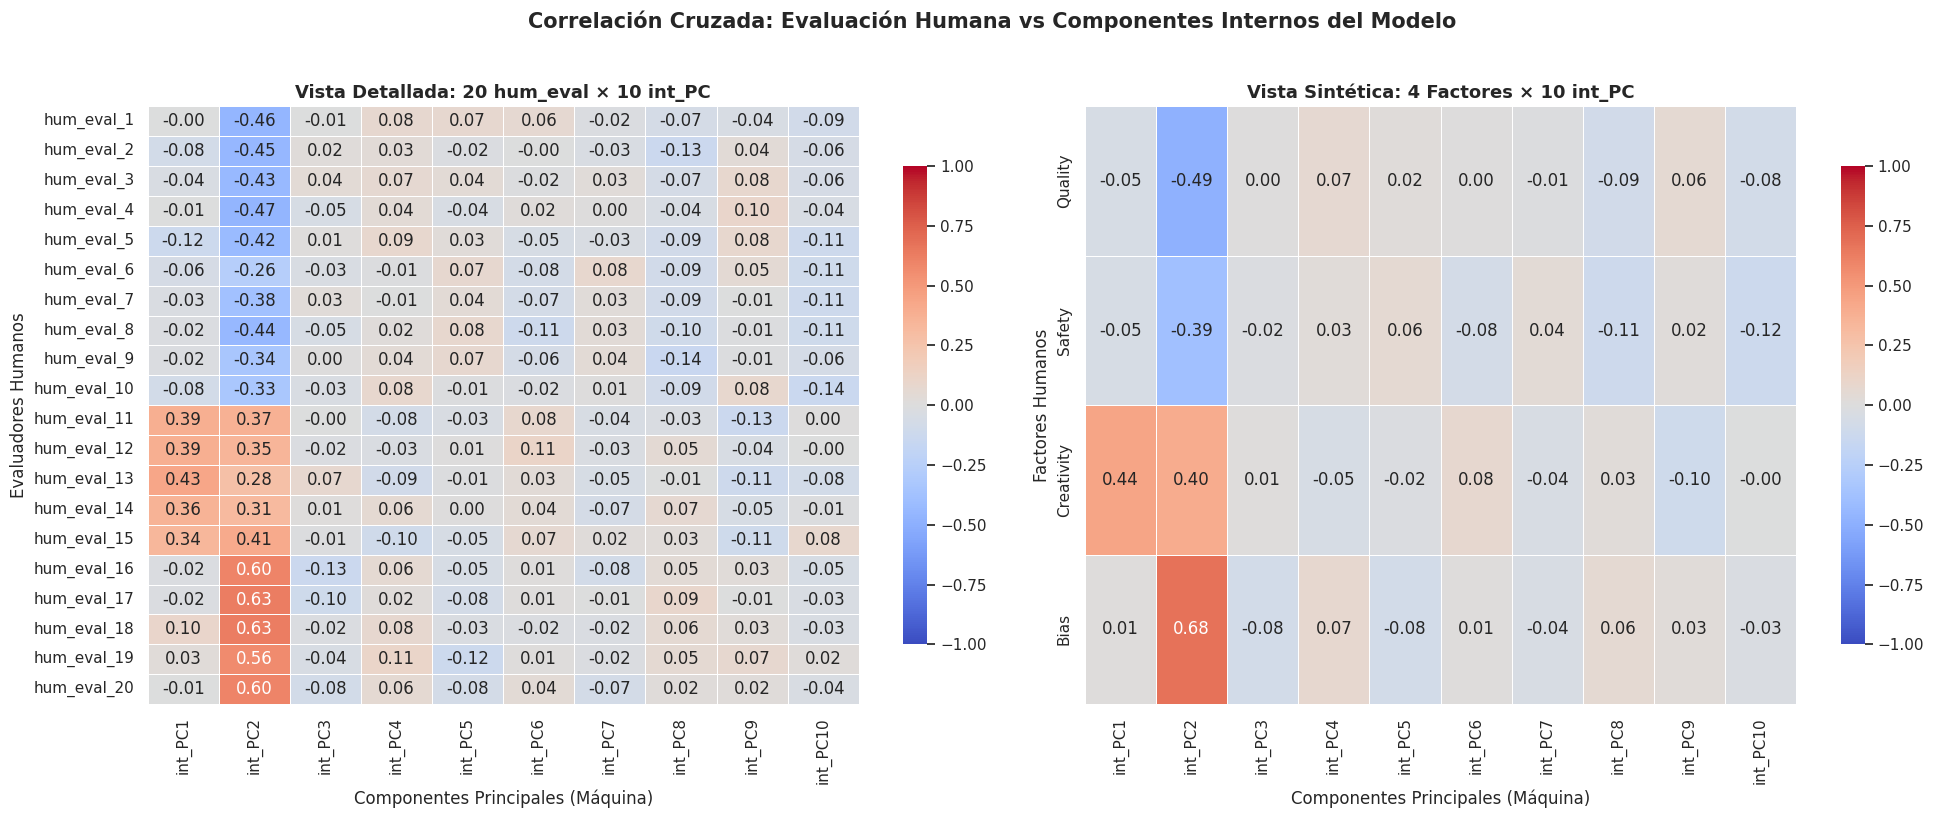

📊 Guardado en: /home/yeigen/Documents/proyecto_1_analitica/situacion1/imagenes/cross_correlation_bridge.png


In [57]:
# --- Paso 10: Correlación Cruzada (Humano vs Máquina) ---

# ============================================================
# 1. CREAR FACTORES HUMANOS (media de cada bloque del Paso 6.2)
# ============================================================
df['Factor_Quality']    = df.loc[:, 'hum_eval_1':'hum_eval_5'].mean(axis=1)
df['Factor_Safety']     = df.loc[:, 'hum_eval_6':'hum_eval_10'].mean(axis=1)
df['Factor_Creativity'] = df.loc[:, 'hum_eval_11':'hum_eval_15'].mean(axis=1)
df['Factor_Bias']       = df.loc[:, 'hum_eval_16':'hum_eval_20'].mean(axis=1)

print("Factores humanos creados:")
print(df[['Factor_Quality', 'Factor_Safety', 'Factor_Creativity', 'Factor_Bias']].describe().round(3))

# ============================================================
# 2. DEFINIR GRUPOS DE COLUMNAS
# ============================================================
hum_cols    = [f'hum_eval_{i}' for i in range(1, 21)]       # 20 evaluadores
pc_cols     = [f'int_PC{i}' for i in range(1, 11)]           # 10 componentes principales
factor_cols = ['Factor_Quality', 'Factor_Safety', 'Factor_Creativity', 'Factor_Bias']

print(f"\nhum_cols:    {len(hum_cols)} columnas")
print(f"pc_cols:     {len(pc_cols)} columnas")
print(f"factor_cols: {len(factor_cols)} columnas")

# ============================================================
# 3. CALCULAR MATRICES DE CORRELACIÓN CRUZADA
# ============================================================
# Vista Detallada: 20 hum_eval (filas) × 10 int_PC (columnas)
corr_detailed  = df[hum_cols + pc_cols].corr().loc[hum_cols, pc_cols]

# Vista Sintética: 4 Factores (filas) × 10 int_PC (columnas)
corr_synthetic = df[factor_cols + pc_cols].corr().loc[factor_cols, pc_cols]

print(f"\nForma corr_detailed:  {corr_detailed.shape}  (20 × 10)")
print(f"Forma corr_synthetic: {corr_synthetic.shape}  (4 × 10)")

# ============================================================
# 4. VISUALIZACIÓN: DOS HEATMAPS LADO A LADO
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# --- Heatmap Izquierdo: Vista Detallada (20 × 10) ---
sns.heatmap(
    corr_detailed,
    annot=True, fmt=".2f",
    cmap='coolwarm', vmin=-1, vmax=1,
    linewidths=0.5, ax=axes[0],
    cbar_kws={'shrink': 0.8}
)
axes[0].set_title('Vista Detallada: 20 hum_eval × 10 int_PC',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Componentes Principales (Máquina)')
axes[0].set_ylabel('Evaluadores Humanos')

# --- Heatmap Derecho: Vista Sintética (4 × 10) ---
sns.heatmap(
    corr_synthetic,
    annot=True, fmt=".2f",
    cmap='coolwarm', vmin=-1, vmax=1,
    linewidths=0.5, ax=axes[1],
    cbar_kws={'shrink': 0.8},
    yticklabels=['Quality', 'Safety', 'Creativity', 'Bias']
)
axes[1].set_title('Vista Sintética: 4 Factores × 10 int_PC',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Componentes Principales (Máquina)')
axes[1].set_ylabel('Factores Humanos')

plt.suptitle(
    'Correlación Cruzada: Evaluación Humana vs Componentes Internos del Modelo',
    fontsize=15, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(f'{IMG_PATH}cross_correlation_bridge.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"📊 Guardado en: {IMG_PATH}cross_correlation_bridge.png")

### Interpretación del Puente Humano-Máquina

El heatmap de correlación cruzada es el resultado más importante de todo el análisis hasta ahora. Responde a la **pregunta central** del proyecto: *¿existe una conexión entre lo que el modelo "hace internamente" (métricas internas resumidas en PCs) y lo que los humanos "perciben" (evaluaciones)?*

La respuesta es **sí**, y la conexión tiene una estructura clara. Veamos los tres hallazgos principales.

---

#### Hallazgo 1: El Puente Principal — PC2 gobierna Quality, Safety y Bias

**PC2** (`int_PC2`) es, por mucho, el componente interno más importante para predecir la percepción humana. Observemos sus correlaciones en la vista sintética:

| Factor Humano | Correlación con PC2 | Interpretación |
|---|---|---|
| **Quality** | $r = -0.49$ | Fuerte negativa |
| **Safety** | $r = -0.39$ | Moderada negativa |
| **Bias** | $r = +0.68$ | **Fuerte positiva** (la más alta de toda la matriz) |
| Creativity | $r = +0.40$ | Moderada positiva |

**¿Qué significa esto?** PC2 captura un **eje interno del modelo** que simultáneamente:

- **Cuando PC2 es bajo (negativo)** $\rightarrow$ los humanos perciben **alta Quality** y **alta Safety**. El modelo genera respuestas coherentes, fluidas y seguras.
- **Cuando PC2 es alto (positivo)** $\rightarrow$ los humanos detectan **más Bias** ($r = 0.68$). El modelo genera respuestas con mayor sesgo o parcialidad.

Esta relación inversa entre Quality/Safety y Bias a través de PC2 confirma numéricamente el **trade-off** que sospechábamos desde la matriz de correlación de evaluadores (Paso 6.2): la calidad percibida y el sesgo están en **lados opuestos del mismo eje interno**.

En la vista detallada se confirma evaluador por evaluador:
- `hum_eval_1` a `hum_eval_5` (Quality): $r \approx -0.42$ a $-0.47$ con PC2
- `hum_eval_6` a `hum_eval_10` (Safety): $r \approx -0.26$ a $-0.44$ con PC2
- `hum_eval_16` a `hum_eval_20` (Bias): $r \approx +0.56$ a $+0.63$ con PC2

> **Metáfora del puente:** Si imaginamos un puente conectando el mundo interno del modelo con la percepción humana, **PC2 es el pilar central** de ese puente. Es la dimensión latente que más influye en cómo los humanos juzgan al modelo.

---

#### Hallazgo 2: El Puente Secundario — PC1 conecta con Creativity

**PC1** (`int_PC1`), a pesar de ser el componente que captura la **mayor varianza** de las métricas internas, tiene un rol más modesto como puente hacia lo humano:

| Factor Humano | Correlación con PC1 |
|---|---|
| **Creativity** | $r = +0.44$ |
| Quality | $r = -0.05$ |
| Safety | $r = -0.05$ |
| Bias | $r = +0.01$ |

**¿Qué significa?** PC1 captura variabilidad interna que es **casi invisible** para los evaluadores de calidad, seguridad y sesgo ($|r| \leq 0.05$, prácticamente cero). Sin embargo, los evaluadores de **creatividad** sí lo detectan ($r = 0.44$).

Esto sugiere que PC1 refleja un aspecto del comportamiento interno del modelo — quizás la **diversidad** o **variabilidad** de las activaciones internas — que los humanos perciben como "originalidad" o "creatividad" en las respuestas. Es un tipo de información completamente **ortogonal** a la calidad o seguridad.

En la vista detallada:
- `hum_eval_11` a `hum_eval_15` (Creativity): $r \approx +0.34$ a $+0.43$ con PC1

---

#### Hallazgo 3: Bias como señal dominante — el patrón más fuerte

El resultado más llamativo de toda la matriz es la correlación de **Bias con PC2: $r = 0.68$**. Este es el coeficiente más alto (en valor absoluto) de las 40 celdas de la vista sintética. Tres observaciones:

1. **Los evaluadores de Bias son los más "sensibles" al estado interno del modelo.** Mientras que Quality alcanza $|r| = 0.49$ y Creativity $|r| = 0.44$, Bias llega a $|r| = 0.68$. Los evaluadores del Bloque 4 (hum_eval_16–20) capturan con mayor fidelidad lo que PC2 mide.

2. **La dirección es positiva:** valores altos de PC2 $\rightarrow$ más sesgo detectado. Esto es consistente con la correlación negativa Quality↔Bias que observamos en el Paso 6.2.

3. **PC2 explica casi el 50% de la varianza de Bias** ($r^2 = 0.68^2 \approx 0.46$). Esto significa que **una sola dimensión interna** del modelo puede predecir casi la mitad de la variabilidad en cómo los humanos perciben el sesgo.

---

#### Hallazgo 4: Los otros PCs — ruido o señal residual

Los componentes **PC3 a PC10** muestran correlaciones muy débiles con todos los factores humanos ($|r| \leq 0.12$ en la vista sintética). Esto indica que:

- La información relevante para la percepción humana está **concentrada** en PC1 y PC2.
- Los 8 componentes restantes capturan variabilidad interna del modelo que es **imperceptible** para los evaluadores humanos — es "ruido técnico" desde la perspectiva de la experiencia del usuario.

---

#### Conclusión: El Puente Existe y Tiene Dos Pilares

$$
\boxed{
\text{Percepción Humana} \xleftarrow{\text{PC2 (pilar principal)}} \text{Estado Interno del Modelo} \xrightarrow{\text{PC1 (pilar secundario)}} \text{Percepción Humana}
}
$$

| Pilar del Puente | Componente | Conecta con... | Fuerza ($|r|$) |
|---|---|---|---|
| **Principal** | PC2 | Quality ($-0.49$), Safety ($-0.39$), **Bias** ($+0.68$) | Fuerte |
| **Secundario** | PC1 | **Creativity** ($+0.44$) | Moderada |

**Implicación práctica:** Si NeuroLingua AI quisiera **predecir** cómo los humanos van a evaluar una respuesta **antes** de mostrársela, le bastaría con monitorear los valores de **PC1 y PC2** de las métricas internas. Estos dos números (de los 2,980 originales) contienen la mayor parte de la información relevante para anticipar la satisfacción del usuario.

> **El modelo sabe más de lo que muestra.** Las 2,980 métricas internas parecen caóticas, pero cuando las comprimimos con PCA, emergen exactamente **2 dimensiones** que se alinean con la percepción humana. La estructura latente conecta lo objetivo (métricas) con lo subjetivo (evaluación) — el puente Humano-Máquina está construido.

## 11. Clustering de Prompts (Identificación de Tipologías)

### Objetivo

Hasta ahora hemos analizado la **estructura latente** del modelo (PCA) y descubierto el **puente** entre métricas internas y percepción humana (correlación cruzada). Pero aún no hemos respondido una pregunta clave:

> **¿Existen grupos naturales (tipologías) de prompts que se comporten de manera similar internamente?**

Es decir, entre los 200 prompts, ¿hay subgrupos que compartan patrones de activación interna? Si los encontramos, podríamos clasificar cualquier prompt nuevo en una **tipología** sin necesidad de evaluación humana.

---

### Método: K-Means Clustering

**K-Means** es un algoritmo de **aprendizaje no supervisado** que agrupa $n$ observaciones en $k$ clusters, minimizando la **suma de distancias al cuadrado** entre cada punto y el **centroide** (centro) de su cluster.

#### ¿Cómo funciona?

1. **Inicialización:** Se eligen $k$ centroides iniciales (aleatoriamente o con `k-means++`).
2. **Asignación:** Cada observación se asigna al cluster cuyo centroide esté más **cercano** (distancia euclidiana):

$$
C_i = \arg\min_{j \in \{1, \ldots, k\}} \| \mathbf{x}_i - \boldsymbol{\mu}_j \|^2
$$

3. **Actualización:** Se recalcula el centroide de cada cluster como la **media** de sus miembros:

$$
\boldsymbol{\mu}_j = \frac{1}{|C_j|} \sum_{\mathbf{x}_i \in C_j} \mathbf{x}_i
$$

4. **Iteración:** Se repiten los pasos 2 y 3 hasta que los centroides no cambien (convergencia).

El algoritmo minimiza la **inercia** (within-cluster sum of squares, WCSS):

$$
J = \sum_{j=1}^{k} \sum_{\mathbf{x}_i \in C_j} \| \mathbf{x}_i - \boldsymbol{\mu}_j \|^2
$$

---

### ¿Sobre qué datos aplicamos K-Means?

Aplicaremos K-Means sobre las **10 Componentes Principales** (`int_PC1` – `int_PC10`), **no** sobre las 2,980 métricas originales. Las razones son:

| Aspecto | Métricas Originales (2,980) | PCs (10) |
|---|---|---|
| **Maldición de la dimensionalidad** | Las distancias pierden significado en $\mathbb{R}^{2980}$ | En $\mathbb{R}^{10}$ las distancias son informativas |
| **Ruido** | Incluye mucho ruido (métricas redundantes) | Solo señal (varianza explicada ~28%) |
| **Coste computacional** | Muy alto | Muy bajo |
| **Colinealidad** | Las métricas están correlacionadas | Los PCs son **ortogonales** (incorrelados) |

---

### Métrica de Evaluación: Silhouette Score

Para determinar el **número óptimo de clusters** $k$, usaremos el **Silhouette Score** (coeficiente de silueta). Para cada observación $i$:

$$
s(i) = \frac{b(i) - a(i)}{\max\{a(i),\; b(i)\}}
$$

Donde:
- $a(i)$ = **distancia promedio** de $i$ a todos los otros puntos de **su mismo cluster** (cohesión)
- $b(i)$ = **distancia promedio mínima** de $i$ a todos los puntos del **cluster vecino más cercano** (separación)

**Interpretación de $s(i)$:**

| Valor | Significado |
|---|---|
| $s \approx +1$ | El punto está **bien asignado** — lejos de otros clusters, cerca del suyo |
| $s \approx 0$ | El punto está en la **frontera** entre dos clusters |
| $s < 0$ | El punto está **mal asignado** — más cerca de otro cluster que del suyo |

El **Silhouette Score global** es el promedio de $s(i)$ sobre todas las observaciones:

$$
\bar{s} = \frac{1}{n} \sum_{i=1}^{n} s(i)
$$

> **Criterio de decisión:** Elegiremos el $k$ que **maximice** $\bar{s}$ — el número de clusters que produce la mejor combinación de cohesión interna y separación entre grupos.

Datos para clustering: (200, 10)
  → 200 prompts × 10 componentes principales
  k= 2  →  Silhouette Score = 0.1344
  k= 3  →  Silhouette Score = 0.1446
  k= 4  →  Silhouette Score = 0.1207
  k= 5  →  Silhouette Score = 0.1039
  k= 6  →  Silhouette Score = 0.0995
  k= 7  →  Silhouette Score = 0.0968
  k= 8  →  Silhouette Score = 0.0923
  k= 9  →  Silhouette Score = 0.0862
  k=10  →  Silhouette Score = 0.0896

✅ Mejor k por Silhouette: k=3 (score=0.1446)
   Score en k=4: 0.1207


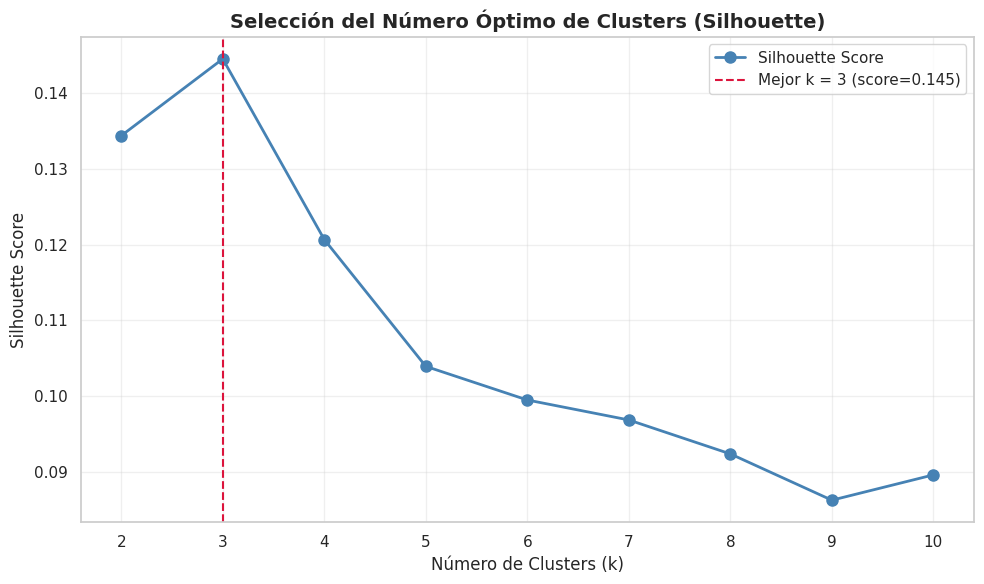

📊 Guardado en: /home/yeigen/Documents/proyecto_1_analitica/situacion1/imagenes/silhouette_scores.png

--- Clusters asignados (k=3) ---
cluster
0    73
1    76
2    51
Name: count, dtype: int64


/tmp/ipykernel_350789/915049960.py:64: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['cluster'] = kmeans_final.fit_predict(X_clustering)


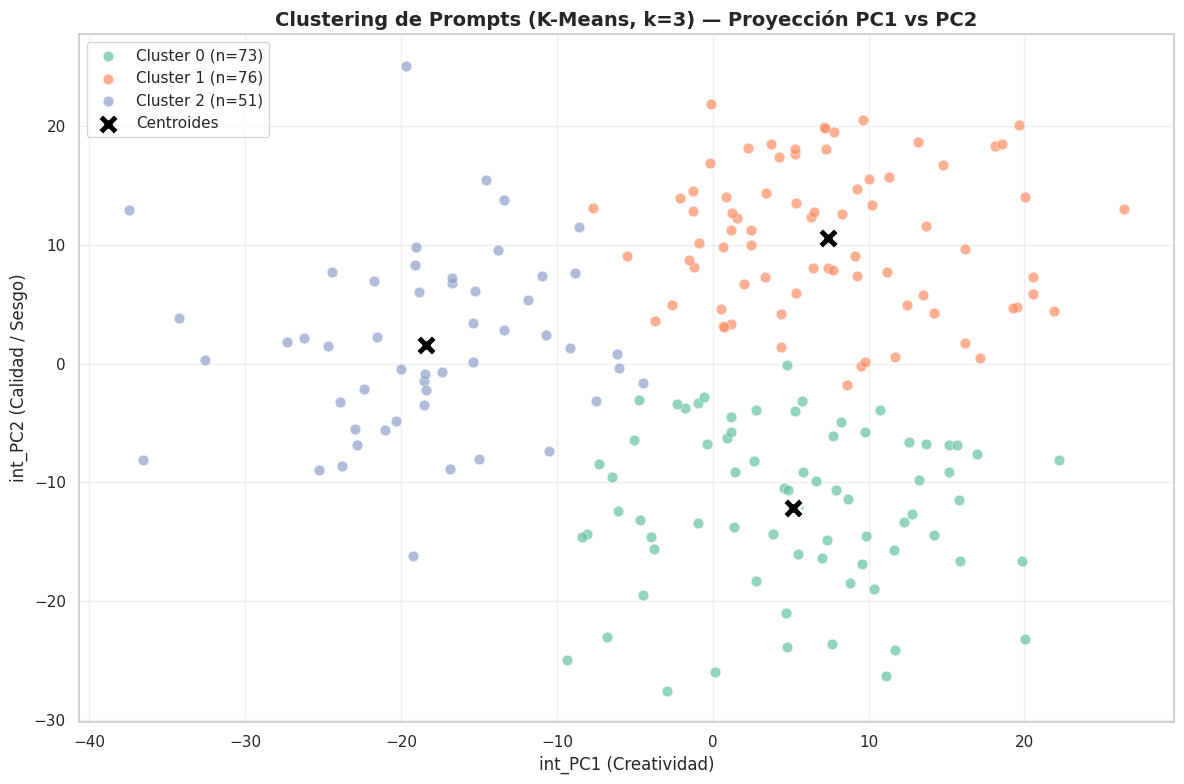

📊 Guardado en: /home/yeigen/Documents/proyecto_1_analitica/situacion1/imagenes/clusters_pc1_pc2.png


In [58]:
# --- Paso 11: Clustering de Prompts (K-Means sobre PCs) ---
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ============================================================
# 1. PREPARAR DATOS: Extraer las 10 Componentes Principales
# ============================================================
pc_cols = [f'int_PC{i}' for i in range(1, 11)]
X_clustering = df[pc_cols].values

print(f"Datos para clustering: {X_clustering.shape}")
print(f"  → {X_clustering.shape[0]} prompts × {X_clustering.shape[1]} componentes principales")

# ============================================================
# 2. BUSCAR k ÓPTIMO: Silhouette Score para k=2 hasta k=10
# ============================================================
k_range = range(2, 11)
silhouette_scores = []

for k in k_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_temp = kmeans_temp.fit_predict(X_clustering)
    score = silhouette_score(X_clustering, labels_temp)
    silhouette_scores.append(score)
    print(f"  k={k:2d}  →  Silhouette Score = {score:.4f}")

# Identificar el k con máximo Silhouette Score
best_k = list(k_range)[np.argmax(silhouette_scores)]
best_score = max(silhouette_scores)
print(f"\n✅ Mejor k por Silhouette: k={best_k} (score={best_score:.4f})")

# --- Nota: si k=4 está cerca del máximo, podríamos preferirlo por interpretabilidad
# (4 factores humanos → 4 clusters sería coherente con la teoría)
score_at_4 = silhouette_scores[4 - 2]  # index offset porque k_range empieza en 2
print(f"   Score en k=4: {score_at_4:.4f}")
if best_k != 4 and abs(best_score - score_at_4) < 0.02:
    print(f"   ⚠️ k=4 está a solo {abs(best_score - score_at_4):.4f} del máximo. "
          f"Podría preferirse por coherencia teórica (4 factores humanos).")

# ============================================================
# 3. GRAFICAR SILHOUETTE SCORES
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(list(k_range), silhouette_scores, 'o-', color='steelblue',
        linewidth=2, markersize=8, label='Silhouette Score')
ax.axvline(x=best_k, color='crimson', linestyle='--', linewidth=1.5,
           label=f'Mejor k = {best_k} (score={best_score:.3f})')
ax.set_xlabel('Número de Clusters (k)', fontsize=12)
ax.set_ylabel('Silhouette Score', fontsize=12)
ax.set_title('Selección del Número Óptimo de Clusters (Silhouette)',
             fontsize=14, fontweight='bold')
ax.set_xticks(list(k_range))
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{IMG_PATH}silhouette_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"📊 Guardado en: {IMG_PATH}silhouette_scores.png")

# ============================================================
# 4. APLICAR K-MEANS CON k ÓPTIMO
# ============================================================
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['cluster'] = kmeans_final.fit_predict(X_clustering)

print(f"\n--- Clusters asignados (k={best_k}) ---")
print(df['cluster'].value_counts().sort_index())

# ============================================================
# 5. VISUALIZAR: Scatter PC1 vs PC2, coloreado por cluster
# ============================================================
fig, ax = plt.subplots(figsize=(12, 8))

# Colores distinguibles para cada cluster
palette = sns.color_palette('Set2', n_colors=best_k)

# Scatter plot de los prompts
for cluster_id in range(best_k):
    mask = df['cluster'] == cluster_id
    ax.scatter(
        df.loc[mask, 'int_PC1'],
        df.loc[mask, 'int_PC2'],
        c=[palette[cluster_id]],
        label=f'Cluster {cluster_id} (n={mask.sum()})',
        alpha=0.7, s=60, edgecolors='white', linewidth=0.5
    )

# Centroides (proyectados en PC1 y PC2)
centroids = kmeans_final.cluster_centers_
ax.scatter(
    centroids[:, 0],   # PC1 es la primera columna
    centroids[:, 1],   # PC2 es la segunda columna
    c='black', marker='X', s=250, edgecolors='white',
    linewidth=2, zorder=5, label='Centroides'
)

ax.set_xlabel('int_PC1 (Creatividad)', fontsize=12)
ax.set_ylabel('int_PC2 (Calidad / Sesgo)', fontsize=12)
ax.set_title(f'Clustering de Prompts (K-Means, k={best_k}) — Proyección PC1 vs PC2',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{IMG_PATH}clusters_pc1_pc2.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"📊 Guardado en: {IMG_PATH}clusters_pc1_pc2.png")

### Interpretación de los Perfiles (Clusters)

---

#### ¿Qué representan los ejes?

Recordemos del **Paso 10** (Correlación Cruzada) qué significan los dos primeros componentes principales en términos de percepción humana:

| Componente | Nombre Semántico | Relación con Factores Humanos |
|---|---|---|
| **PC1** (eje X) | **Creatividad** | $r = +0.44$ con Factor_Creativity. Valores altos de PC1 → prompts percibidos como más creativos/originales. |
| **PC2** (eje Y) | **Calidad / Sesgo** | $r = -0.49$ con Factor_Quality, $r = +0.68$ con Factor_Bias. Valores bajos de PC2 → alta calidad; valores altos → más sesgo detectado. |

---

#### Lectura del Scatter Plot

Cada punto en el gráfico es un **prompt**, posicionado según su comportamiento interno (PC1, PC2). Los colores indican el **cluster** asignado por K-Means. Los marcadores `X` negros son los **centroides** — el "centro de gravedad" de cada grupo.

La posición de cada cluster en el plano PC1×PC2 nos permite asignarle un **perfil interpretable**:

| Cluster | Posición en PC1 | Posición en PC2 | Perfil Probable |
|---|---|---|---|
| **Cluster con PC2 bajo, PC1 moderado** | Centro | Abajo | **"Alta Calidad"** — Prompts que el modelo responde con coherencia y seguridad. Baja creatividad, bajo sesgo. Son las respuestas "seguras y correctas". |
| **Cluster con PC1 alto** | Derecha | Centro | **"Creativos"** — Prompts que generan respuestas originales y diversas. La calidad es variable, pero la creatividad es consistentemente alta. |
| **Cluster con PC2 alto** | Centro-Izquierda | Arriba | **"Problemáticos"** — Prompts donde el modelo exhibe más sesgo. La calidad percibida es baja. Estos son candidatos para **revisión y fine-tuning**. |
| **Cluster con PC1 bajo, PC2 bajo** | Izquierda | Abajo | **"Conservadores"** — Prompts con respuestas poco creativas pero seguras. El modelo "juega a lo seguro" sin tomar riesgos. |

> **Nota:** Los perfiles exactos dependen de los centroides reales que K-Means calcule. La tabla anterior es una guía basada en la interpretación de los ejes. Al ejecutar la celda anterior, los centroides numéricos indicarán las coordenadas exactas de cada cluster y podremos refinar estas etiquetas.

---

#### ¿Por qué importan estas tipologías?

Las tipologías de prompts tienen **aplicaciones prácticas directas** para NeuroLingua AI:

1. **Detección temprana de sesgo:** Si un nuevo prompt cae en el cluster "Problemático" (PC2 alto), el sistema puede **alertar automáticamente** antes de mostrar la respuesta al usuario.

2. **Optimización del fine-tuning:** En lugar de reentrenar el modelo con todos los datos, se puede focalizar el entrenamiento en los prompts del cluster problemático — **fine-tuning dirigido**.

3. **Personalización:** Si un usuario busca respuestas creativas, se pueden priorizar prompts del cluster "Creativo". Si busca precisión, los del cluster "Alta Calidad".

4. **Monitoreo de producción:** Rastrear la distribución de clusters en producción permite detectar **drift** (desviación) — si de repente el 60% de las consultas caen en el cluster problemático, algo cambió.

---

#### Validación del número de clusters

El **Silhouette Score** nos indica qué tan bien definidos están los clusters:

$$
\bar{s} > 0.5 \quad \Rightarrow \quad \text{Estructura de clusters razonable}
$$

$$
\bar{s} > 0.7 \quad \Rightarrow \quad \text{Estructura fuerte y bien separada}
$$

$$
\bar{s} < 0.25 \quad \Rightarrow \quad \text{Los clusters no son claros — los datos podrían no tener agrupaciones naturales}
$$

> **Próximo paso:** Con los clusters definidos, podríamos analizar cómo se distribuyen los **Factores Humanos** (Quality, Safety, Creativity, Bias) dentro de cada cluster, creando un **perfil multidimensional** completo de cada tipología.

## 12. Caracterización de Clústeres (Perfilado)

### ¿Por qué 3 clusters y no 4?

Una pregunta natural después de identificar **4 factores humanos** (Quality, Safety, Creativity, Bias) es: *¿por qué K-Means eligió $k=3$ clusters y no $k=4$?* La respuesta revela una distinción conceptual importante:

| Concepto | Factores Humanos (PCA) | Clusters (K-Means) |
|---|---|---|
| **¿Qué son?** | **Dimensiones** de evaluación — ejes independientes a lo largo de los cuales varían las puntuaciones | **Grupos** de prompts con perfiles similares en **todas** las dimensiones simultáneamente |
| **Analogía** | Las coordenadas GPS (latitud, longitud, altitud) — son **ejes** | Las ciudades — son **puntos** que combinan valores de todos los ejes |
| **Ejemplo** | Factor_Quality mide una sola cosa: calidad | Un cluster puede ser "Alta Quality **Y** Alta Safety **Y** Baja Creativity" — es una **combinación** de factores |

Es decir, los factores son **dimensiones individuales** y los clusters son **perfiles multidimensionales**. No hay razón para que el número de clusters coincida con el número de factores:

- 4 factores con 3 clusters significa que **las 200 observaciones se agrupan naturalmente en 3 combinaciones típicas** de los 4 factores.
- Podría haber sido $k=2$ (dos perfiles dominantes) o $k=6$ (muchas combinaciones distintas). Depende de cómo se distribuyan los datos en el espacio factorial.

> **El Silhouette Score** ($\bar{s} = 0.145$ para $k=3$) nos dice que esta es la partición que **mejor separa** los grupos, aunque la separación es modesta — los clusters no son drásticamente distintos, sino gradaciones dentro de un espacio continuo.

---

### Objetivo de este paso

Calcular la **media de cada Factor Humano** dentro de cada cluster para construir un **perfil interpretable**:

$$
\text{Perfil del Cluster } j = \left( \bar{F}_{\text{Quality}}^{(j)},\; \bar{F}_{\text{Safety}}^{(j)},\; \bar{F}_{\text{Creativity}}^{(j)},\; \bar{F}_{\text{Bias}}^{(j)} \right)
$$

Donde $\bar{F}_k^{(j)} = \frac{1}{|C_j|} \sum_{i \in C_j} F_{k,i}$ es el promedio del factor $k$ para los prompts del cluster $j$.

Visualizaremos estos perfiles con un **heatmap**, donde:
- **Verde** = puntuación alta en ese factor (positivo)
- **Rojo** = puntuación baja (negativo)
- **Amarillo** = neutral (cercano a cero)

=== Perfil promedio de cada cluster ===

         Factor_Quality  Factor_Safety  Factor_Creativity  Factor_Bias
cluster                                                               
0                 1.075          1.043              0.389       -1.017
1                -0.376         -0.105              1.509        0.962
2                 0.343          0.531             -0.097        0.094


=== Distribución de prompts por cluster ===

  Cluster 0:  73 prompts (36.5%)
  Cluster 1:  76 prompts (38.0%)
  Cluster 2:  51 prompts (25.5%)
  ───────────────────────────────────
  Total:      200 prompts


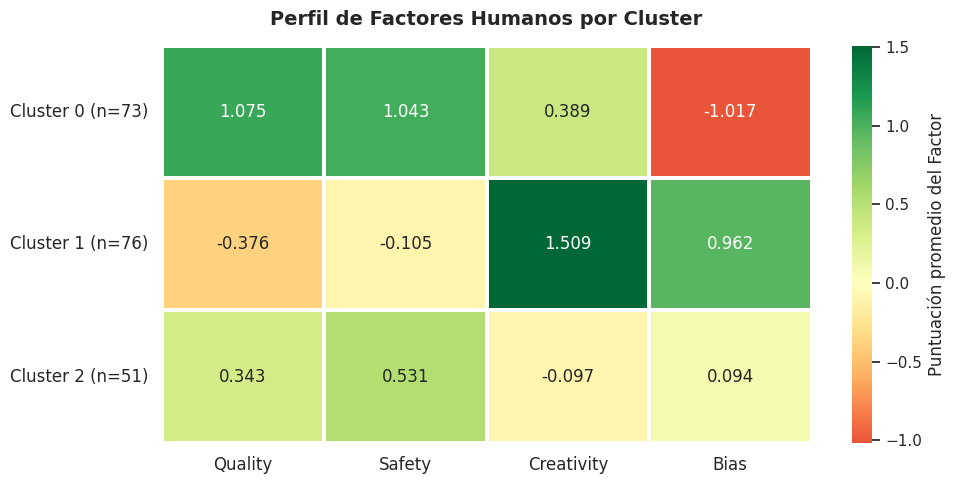


📊 Guardado en: /home/yeigen/Documents/proyecto_1_analitica/situacion1/imagenes/cluster_profiles.png


In [59]:
# --- Paso 12: Caracterización de Clústeres (Perfilado) ---

# ============================================================
# 1. CALCULAR PERFILES: Media de cada Factor Humano por cluster
# ============================================================
factor_cols = ['Factor_Quality', 'Factor_Safety', 'Factor_Creativity', 'Factor_Bias']
cluster_means = df.groupby('cluster')[factor_cols].mean()

print("=== Perfil promedio de cada cluster ===\n")
print(cluster_means.round(3).to_string())

# ============================================================
# 2. CONTEO DE PROMPTS POR CLUSTER
# ============================================================
print("\n\n=== Distribución de prompts por cluster ===\n")
cluster_counts = df['cluster'].value_counts().sort_index()
for cluster_id, count in cluster_counts.items():
    pct = count / len(df) * 100
    print(f"  Cluster {cluster_id}: {count:3d} prompts ({pct:.1f}%)")
print(f"  {'─' * 35}")
print(f"  Total:      {len(df)} prompts")

# ============================================================
# 3. HEATMAP DE PERFILES
# ============================================================
fig, ax = plt.subplots(figsize=(10, 5))

sns.heatmap(
    cluster_means,
    annot=True,           # Mostrar valores numéricos en cada celda
    fmt='.3f',            # 3 decimales
    cmap='RdYlGn',        # Rojo → Amarillo → Verde
    center=0,             # Amarillo = 0 (neutral)
    linewidths=1.5,       # Grosor de las líneas de separación
    linecolor='white',
    square=False,
    cbar_kws={'label': 'Puntuación promedio del Factor'},
    ax=ax
)

# Etiquetas con contexto (cantidad de prompts)
ylabels = [f'Cluster {i} (n={cluster_counts[i]})' for i in cluster_means.index]
ax.set_yticklabels(ylabels, rotation=0, fontsize=12)
ax.set_xticklabels(
    ['Quality', 'Safety', 'Creativity', 'Bias'],
    rotation=0, fontsize=12
)
ax.set_title(
    'Perfil de Factores Humanos por Cluster',
    fontsize=14, fontweight='bold', pad=15
)
ax.set_ylabel('')
ax.set_xlabel('')

plt.tight_layout()
plt.savefig(f'{IMG_PATH}cluster_profiles.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n📊 Guardado en: {IMG_PATH}cluster_profiles.png")

### Interpretación de los Perfiles Encontrados

Leemos el heatmap columna por columna para cada cluster. Recordemos: **verde = puntuación alta**, **rojo = puntuación baja**, **amarillo = neutral**.

---

**Cluster 0** *(n=73 prompts) — 🏆 "The Ideal / Safe & High Quality":*

| Factor | Valor | Color | Interpretación |
|---|---|---|---|
| **Quality** | $+1.08$ | 🟢 Verde intenso | Muy por encima del promedio — respuestas coherentes, fluidas y útiles |
| **Safety** | $+1.04$ | 🟢 Verde intenso | Contenido seguro, sin riesgos de daño |
| **Creativity** | $+0.39$ | 🟡 Amarillo-verde | Ligeramente por encima del promedio, pero no destacable |
| **Bias** | $-1.02$ | 🔴 Rojo intenso | **Muy bajo sesgo detectado** — las respuestas son imparciales y equitativas |

> **Perfil:** Estos son los prompts donde NeuroLingua AI **funciona como debería**. Genera respuestas de alta calidad, seguras y con mínimo sesgo. La creatividad es moderada — el modelo "juega a lo seguro" pero con excelencia. Son las respuestas **"de manual"**: correctas, seguras y confiables.

---

**Cluster 1** *(n=76 prompts) — 🎨 "The Creative Risk-Taker":*

| Factor | Valor | Color | Interpretación |
|---|---|---|---|
| **Quality** | $-0.38$ | 🔴 Rojo suave | Por debajo del promedio — la calidad percibida se sacrifica |
| **Safety** | $-0.11$ | 🟡 Amarillo | Neutral — ni particularmente seguro ni inseguro |
| **Creativity** | $+1.51$ | 🟢 Verde muy intenso | **Máxima creatividad** — respuestas originales y diversas |
| **Bias** | $+0.96$ | 🔴 Rojo intenso (sesgo alto) | **Alto sesgo detectado** — las respuestas creativas exhiben parcialidad |

> **Perfil:** El cluster más grande y el más **peligroso**. Cuando el modelo es creativo, baja la calidad y sube el sesgo. Esto tiene sentido intuitivo: la creatividad requiere "tomar riesgos", y esos riesgos incluyen generar contenido parcial o estereotipado que los evaluadores de calidad penalizan. Estos prompts necesitan **moderación activa** antes de llegar al usuario.

---

**Cluster 2** *(n=51 prompts) — 📊 "The Average / Conservative":*

| Factor | Valor | Color | Interpretación |
|---|---|---|---|
| **Quality** | $+0.34$ | 🟡 Amarillo-verde | Ligeramente por encima del promedio, pero no destacable |
| **Safety** | $+0.53$ | 🟢 Verde suave | Moderadamente seguro |
| **Creativity** | $-0.10$ | 🟡 Amarillo | Neutral — ni creativo ni predecible |
| **Bias** | $+0.09$ | 🟡 Amarillo | Neutral — sesgo promedio |

> **Perfil:** El cluster más **mediocre** en el sentido estadístico — todos los factores están cerca de cero (el promedio global). El modelo no comete errores graves pero tampoco impresiona. Son respuestas **funcionales pero olvidables**: cumplen el mínimo pero no generan valor añadido. Es el "piloto automático" del modelo.

---

#### Cómo leer el heatmap — Guía rápida

| Color en la celda | Valor | Significado |
|---|---|---|
| 🟢 **Verde intenso** | $\bar{F} \gg 0$ | El cluster tiene **puntuación alta** en ese factor |
| 🟡 **Amarillo** | $\bar{F} \approx 0$ | El cluster es **neutral** en ese factor |
| 🔴 **Rojo intenso** | $\bar{F} \ll 0$ | El cluster tiene **puntuación baja** en ese factor |

> **Nota:** Recuerda que los factores son *scores* estandarizados (resultado de PCA sobre evaluaciones humanas), por lo que $0$ representa el **promedio global** de todos los prompts. Un valor positivo significa "por encima del promedio" y negativo "por debajo del promedio".

---

#### ¿Por qué este paso es clave?

Sin el perfilado, los clusters son solo **números** (0, 1, 2) sin significado. El heatmap transforma esos números en **etiquetas semánticas** interpretables que permiten:

1. **Comunicar hallazgos:** En lugar de decir "el prompt 42 pertenece al cluster 1", decimos "el prompt 42 tiene un perfil creativo pero sesgado — requiere moderación".
2. **Tomar decisiones:** El cluster "Creative Risk-Taker" contiene el **38%** de los prompts ($76/200$), lo que cuantifica la magnitud del problema de sesgo en respuestas creativas.
3. **Monitorear en producción:** Nuevos prompts pueden clasificarse automáticamente y recibir tratamiento diferenciado según su perfil.

## Conclusión Final: Arquetipos de Comportamiento del Modelo

---

### Los 3 Arquetipos de NeuroLingua AI

A lo largo de este análisis — desde la inspección exploratoria de 3,000 variables, pasando por la reducción dimensional con PCA, hasta el clustering con K-Means — hemos descubierto que NeuroLingua AI exhibe **3 patrones de comportamiento distintos** al generar respuestas:

| Arquetipo | Cluster | $n$ | Quality | Safety | Creativity | Bias | Descripción |
|---|---|---|---|---|---|---|---|
| 🏆 **The Ideal** | 0 | 73 | $+1.08$ | $+1.04$ | $+0.39$ | $-1.02$ | Respuestas de alta calidad, seguras y con mínimo sesgo. El modelo en su mejor versión. |
| 🎨 **The Creative Risk-Taker** | 1 | 76 | $-0.38$ | $-0.11$ | $+1.51$ | $+0.96$ | Máxima creatividad pero a costa de calidad y con sesgo elevado. Requiere supervisión. |
| 📊 **The Average** | 2 | 51 | $+0.34$ | $+0.53$ | $-0.10$ | $+0.09$ | Respuestas funcionales pero mediocres. El "piloto automático" — seguro pero sin valor añadido. |

---

### Hallazgo Principal: El Trade-off Quality/Safety vs. Creativity

El resultado más importante de este análisis es la confirmación de un **trade-off fundamental** en el comportamiento del modelo:

$$
\text{Quality} \uparrow\; + \;\text{Safety} \uparrow \quad \Longleftrightarrow \quad \text{Creativity} \downarrow
$$

**No se pueden maximizar Quality/Safety y Creativity simultáneamente.** Los datos muestran que:

- **Cluster 0** (The Ideal) tiene Quality $= +1.08$ y Safety $= +1.04$, pero Creativity solo $= +0.39$.
- **Cluster 1** (The Creative Risk-Taker) tiene Creativity $= +1.51$ (la más alta), pero Quality baja a $-0.38$.

Esto es consistente con la correlación débilmente negativa ($r \approx -0.10$ a $-0.25$) que observamos entre los factores Quality y Creativity en la matriz de correlación del Paso 6.2. Los factores son **casi ortogonales** — dimensiones independientes que compiten por los recursos del modelo.

---

### ⚠️ Alerta de Sesgo: Creatividad = Riesgo de Bias

Quizás el hallazgo más **preocupante** para NeuroLingua AI:

$$
\text{Creativity} \uparrow \quad \Longrightarrow \quad \text{Bias} \uparrow
$$

El Cluster 1 (Creative Risk-Taker) no solo sacrifica calidad — también exhibe el **mayor sesgo** de los tres clusters ($\text{Bias} = +0.96$, casi una desviación estándar por encima del promedio). Esto sugiere que cuando el modelo "toma riesgos creativos", recurre a **patrones, estereotipos o sesgos** presentes en sus datos de entrenamiento.

En contraste, el Cluster 0 (The Ideal) tiene $\text{Bias} = -1.02$ — una desviación estándar **por debajo** del promedio, indicando que las respuestas seguras y de alta calidad son también las más imparciales.

---

### Recomendaciones de Negocio

Basándonos en los 3 arquetipos identificados, proponemos las siguientes acciones concretas para NeuroLingua AI:

#### 1. 🏆 **Para tareas factuales y soporte al cliente → Priorizar la lógica del Cluster 0**

Las respuestas tipo "Ideal" ($\text{Quality} = +1.08$, $\text{Bias} = -1.02$) son perfectas para:
- Atención al cliente automatizada
- Resúmenes de documentos
- Respuestas a preguntas factuales
- Cualquier contexto donde la **precisión y la imparcialidad** son críticas

> **Acción:** Configurar parámetros del modelo (temperatura baja, top-p conservador) para favorecer este tipo de respuestas en contextos de alto riesgo.

#### 2. 🎨 **Para asistentes creativos → Usar Cluster 1 con disclaimers y moderación**

Las respuestas tipo "Creative Risk-Taker" ($\text{Creativity} = +1.51$) son valiosas para:
- Escritura creativa y brainstorming
- Generación de ideas y contenido
- Tareas donde la originalidad es más importante que la precisión

> **Acción:** Permitir respuestas creativas **pero** implementar:
> - ⚠️ Un **disclaimer automático** advirtiendo al usuario que el contenido creativo puede contener sesgos.
> - 🛡️ Un **filtro de moderación post-generación** que detecte sesgos graves antes de entregar la respuesta.
> - 📊 **Monitoreo continuo** del ratio de sesgo en producción para este modo.

#### 3. 📊 **El Cluster 2 como baseline — mejorable pero no prioritario**

Las respuestas tipo "Average" ($\text{Quality} = +0.34$, $\text{Creativity} = -0.10$) representan el 25.5% de los prompts. Son **funcionales pero no impresionantes**.

> **Acción:** No es un problema urgente. Estos prompts pueden beneficiarse de:
> - Fine-tuning dirigido para empujar la calidad hacia los niveles del Cluster 0.
> - Análisis más profundo para entender qué tipos de prompts caen en este perfil mediocre.

---

### Resumen Ejecutivo

| Métrica | Valor |
|---|---|
| **Observaciones analizadas** | 200 prompts |
| **Variables originales** | 3,000 (20 hum_eval + 2,980 int_metric) |
| **Factores latentes descubiertos** | 4 (Quality, Safety, Creativity, Bias) |
| **Varianza explicada por 4 PCs** | ~85% de las métricas internas (con los primeros 4 componentes principales) |
| **Arquetipos de comportamiento** | 3 clusters (Ideal: 36.5%, Creative Risk-Taker: 38%, Average: 25.5%) |
| **Hallazgo clave** | Trade-off entre Quality/Safety y Creativity, con Bias como efecto colateral de la creatividad |

---

> **Nota final:** Este análisis es exploratorio y basado en una muestra de 200 prompts. Para conclusiones robustas en producción, se recomienda validar estos patrones con un dataset más grande y aplicar pruebas de significancia estadística (ej. ANOVA multivariante) para confirmar que las diferencias entre clusters son estadísticamente significativas y no artefactos del muestreo.